### Load data

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import scipy.signal as signal
import statsmodels.api as sm
import pandas as pd
from seaborn import regplot
from seaborn import heatmap

In [2]:
def weight_by_latitude(da):
    """Weight data array by cosine of latitude."""
    weights = np.cos(np.deg2rad(da['lat']))
    weighted_da = da * weights
    return weighted_da


def reshape_to_2d(da):
    """Reshape (lat, lon, time) data into 2D matrix (space x time)."""
    space_dim = da['lat'].size * da['lon'].size
    reshaped = da.stack(space=('lat', 'lon')).transpose('time', 'space')
    return reshaped


def compute_covariance_matrix(reshaped_da):
    """Compute the covariance matrix of the data."""
    data = reshaped_da.values
    data = data - np.nanmean(data, axis=0)  # Centering the data
    covariance_matrix = np.cov(data.T)
    return covariance_matrix


def perform_svd(cov_matrix):
    """Perform SVD on the covariance matrix."""
    U, S, Vt = np.linalg.svd(cov_matrix)
    return U, S, Vt


def plot_first_principal_component(reshaped_da, Vt):
    """Plot the first principal component as a map."""
    first_pc = Vt[0, :] #first eigenvector with largest eigenvalue
    pc_map = reshaped_da.isel(time=0).copy() #.isel selects the i you give, make a copy of given array at i
    pc_map.values = first_pc #change the values from before to the first_pc values
    pc_map_unstacked = pc_map.unstack('space')

    plt.figure(figsize=(8, 5))
    pc_map_unstacked.plot(cmap='RdBu')
    plt.title("First Principal Component (Spatial Pattern)")
    plt.show()

    return pc_map_unstacked


def compute_zonal_mean(pc_map_unstacked):
    """Compute the zonal mean of the first principal component map."""
    zonal_mean = pc_map_unstacked.mean(dim='lon')
    return zonal_mean


def make_zonal_mean_map(zonal_mean, da):
    """Create a zonal mean map, assigning each longitude the same value."""
    zonal_map = xr.zeros_like(da.isel(time=0)) #blank map with same dimensions as da
    for lon in zonal_map['lon']:
        zonal_map.loc[{'lon': lon}] = zonal_mean #assign zonal mean value to each longitude
    return zonal_map


def regress_onto_zonal_mean_map(da, zonal_map):
    """Regress original data onto the zonal mean map (time series of coefficients)."""
#flattening data
    zonal_map_flat = zonal_map.stack(space=('lat', 'lon')).values
    data_flat = da.stack(space=('lat', 'lon')).transpose('time', 'space').values
#detrending by removing mean
    zonal_map_flat = zonal_map_flat - np.nanmean(zonal_map_flat)
    data_flat = data_flat - np.nanmean(data_flat, axis=0)

    regression_coefficients = np.dot(data_flat, zonal_map_flat) / np.dot(zonal_map_flat, zonal_map_flat)

    return regression_coefficients


def plot_regression_coefficients(time, regression_coefficients):
    """Plot regression coefficients over time."""
    plt.figure(figsize=(8, 5))
    plt.plot(time, regression_coefficients, label='Regression Coefficients')
    plt.xlabel('Time')
    plt.ylabel('Coefficient')
    plt.title('Regression Coefficients Over Time')
    plt.grid()
    plt.show()
    
def extract_seasonal_data(array, seasons):
    """
    Extract data from the array for specific seasons (months).
    - A subset of the original array with only the data for the specified months.
    """
    # Make sure the 'time' dimension has a 'month' coordinate
    if 'time' in array.coords:
        # Extract month from the 'time' dimension
        months = array['time'].dt.month
        
        # Filter based on the provided seasons (months)
        seasonal_data = array.sel(time=months.isin(seasons))
        
        return seasonal_data
    else:
        raise ValueError("The input array does not contain a 'time' dimension.")
        
def compute_anomaly(array):
    anomaly=array.groupby('time.month')-array.groupby('time.month').mean('time')
    return(anomaly)

def shift_december(da):
    time_df = pd.to_datetime(da['time'])
    # Create a boolean mask for times in December
    time_series=pd.Series(time_df)
    mask = time_series.dt.month == 12
    time_series.loc[mask] = time_series.loc[mask] + pd.DateOffset(years=1)
    # Convert to numpy datetime64[D]
    time_df_upd = time_series.values.astype('datetime64[D]')
    #display(time_df_upd)
    d={'time':time_df_upd}
    da_new=da.assign_coords(d)
    return da_new

def seasonal_average(da):
    da2=da.groupby('time.year').mean('time')
    return(da2)

def stdize_ssavg(da):
    da2=(da-da.mean())/da.std()
    return da2

## Handling seasonal forecasts

In [3]:
hc=xr.open_dataset('/climca/data/SEAS5_SA/data/seas5_single_levels.nc') #variable name is t2m

In [4]:
import xarray as xr
import pandas as pd
import numpy as np
import glob

In [5]:
# Path to your NetCDF file
DATADIR='/climca/data/SEAS5_SA/data'
file = f"{DATADIR}/seas5_single_levels.nc"

# Open the dataset
# chunks is useful because your dataset is huge.
# It avoids loading everything into memory immediately.
ds = xr.open_dataset(
    file,
    chunks={
        "number": 1,
        "forecast_reference_time": 10,
        "forecastMonth": 6
    }
)

print(ds)

<xarray.Dataset> Size: 80GB
Dimensions:                  (number: 51, forecast_reference_time: 250,
                              forecastMonth: 6, latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 198...
  * forecastMonth            (forecastMonth) int64 48B 1 2 3 4 5 6
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
Data variables:
    t2m                      (number, forecast_reference_time, forecastMonth, latitude, longitude) float32 20GB dask.array<chunksize=(1, 10, 6, 37, 72), meta=np.ndarray>
    msl                      (number, forecast_reference_time, forecastMonth, latitude, longitude) float32 20GB dask.array<chunksize=(1, 10, 6, 37, 72), meta=np.ndarray>
    sst                      (number, forecast_reference_time, fo

/tmp/ipykernel_349856/470643735.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "number" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(
/tmp/ipykernel_349856/470643735.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "forecast_reference_time" starting at index 10. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


In [6]:
# ------------------------------------------------------------
# Make sure we have valid_time
# ------------------------------------------------------------
# valid_time = real calendar month of the forecast
#
# Example:
# forecast_reference_time = 1981-09-01
# forecastMonth = 1 -> valid_time = 1981-09-01
# forecastMonth = 2 -> valid_time = 1981-10-01
# forecastMonth = 3 -> valid_time = 1981-11-01
# forecastMonth = 4 -> valid_time = 1981-12-01
# forecastMonth = 5 -> valid_time = 1982-01-01
# forecastMonth = 6 -> valid_time = 1982-02-01

if "valid_time" in ds.data_vars:
    # Sometimes valid_time exists but is stored as a data variable.
    # We promote it to a coordinate.
    ds = ds.set_coords("valid_time")

elif "valid_time" not in ds.coords:
    # If valid_time does not exist, we create it manually.

    init_times = pd.to_datetime(ds["forecast_reference_time"].values)
    lead_months = ds["forecastMonth"].values

    valid_times = []

    for init in init_times:
        valid_times_this_init = []

        for lead in lead_months:
            this_valid_time = init + pd.DateOffset(months=int(lead) - 1)
            valid_times_this_init.append(this_valid_time)

        valid_times.append(valid_times_this_init)

    valid_times = np.array(valid_times, dtype="datetime64[ns]")

    ds = ds.assign_coords(
        valid_time=(
            ("forecast_reference_time", "forecastMonth"),
            valid_times
        )
    )

print(ds["valid_time"])

<xarray.DataArray 'valid_time' (forecast_reference_time: 250, forecastMonth: 6)> Size: 12kB
array([['1981-01-01T00:00:00.000000000', '1981-02-01T00:00:00.000000000',
        '1981-03-01T00:00:00.000000000', '1981-04-01T00:00:00.000000000',
        '1981-05-01T00:00:00.000000000', '1981-06-01T00:00:00.000000000'],
       ['1981-02-01T00:00:00.000000000', '1981-03-01T00:00:00.000000000',
        '1981-04-01T00:00:00.000000000', '1981-05-01T00:00:00.000000000',
        '1981-06-01T00:00:00.000000000', '1981-07-01T00:00:00.000000000'],
       ['1981-09-01T00:00:00.000000000', '1981-10-01T00:00:00.000000000',
        '1981-11-01T00:00:00.000000000', '1981-12-01T00:00:00.000000000',
        '1982-01-01T00:00:00.000000000', '1982-02-01T00:00:00.000000000'],
       ...,
       ['2022-02-01T00:00:00.000000000', '2022-03-01T00:00:00.000000000',
        '2022-04-01T00:00:00.000000000', '2022-05-01T00:00:00.000000000',
        '2022-06-01T00:00:00.000000000', '2022-07-01T00:00:00.000000000'],
    

In [7]:
def make_3_month_block(ds, lead_months, block_name):
    """
    Select a 3-month forecast block.

    lead_months can be:
        [1, 2, 3]
        [4, 5, 6]

    block_name is just a label:
        "lead_1_2_3"
        "lead_4_5_6"
    """

    block = ds.sel(forecastMonth=lead_months)

    block = block.assign_coords(
        original_forecastMonth=("forecastMonth", lead_months)
    )

    block = block.rename({"forecastMonth": "season_month"})

    block = block.assign_coords(
        season_month=[1, 2, 3]
    )

    block = block.assign_coords(
        lead_block=block_name
    )

    return block

In [8]:
block_1 = make_3_month_block(ds, [1, 2, 3], "lead_1_2_3")
block_2 = make_3_month_block(ds, [4, 5, 6], "lead_4_5_6")

In [9]:
ds_3m = xr.concat(
    [block_1, block_2],
    dim=xr.DataArray(
        ["lead_1_2_3", "lead_4_5_6"],
        dims="lead_block",
        name="lead_block"
    )
)

print(ds_3m)

/tmp/ipykernel_349856/715065168.py:1: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  ds_3m = xr.concat(


<xarray.Dataset> Size: 80GB
Dimensions:                  (lead_block: 2, number: 51,
                              forecast_reference_time: 250, season_month: 3,
                              latitude: 181, longitude: 360)
Coordinates:
  * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
  * forecast_reference_time  (forecast_reference_time) datetime64[ns] 2kB 198...
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    valid_time               (lead_block, forecast_reference_time, season_month) datetime64[ns] 12kB ...
    original_forecastMonth   (lead_block, season_month) int64 48B 1 2 3 4 5 6
  * season_month             (season_month) int64 24B 1 2 3
  * lead_block               (lead_block) <U10 80B 'lead_1_2_3' 'lead_4_5_6'
Data variables:
    t2m                      (lead_block, number, forecast_reference_time, season_month, latitude, longitude

In [10]:
ds_3m = ds_3m.stack(
    sample=("lead_block", "forecast_reference_time", "number")
)

ds_3m = ds_3m.transpose(
    "sample",
    "season_month",
    "latitude",
    "longitude"
)

print(ds_3m)

<xarray.Dataset> Size: 80GB
Dimensions:                  (season_month: 3, latitude: 181, longitude: 360,
                              sample: 25500)
Coordinates:
  * latitude                 (latitude) float64 1kB 90.0 89.0 ... -89.0 -90.0
  * longitude                (longitude) float64 3kB 0.0 1.0 2.0 ... 358.0 359.0
    valid_time               (sample, season_month) datetime64[ns] 612kB 1981...
    original_forecastMonth   (sample, season_month) int64 612kB 1 2 3 ... 4 5 6
  * season_month             (season_month) int64 24B 1 2 3
  * sample                   (sample) object 204kB MultiIndex
  * lead_block               (sample) <U10 1MB 'lead_1_2_3' ... 'lead_4_5_6'
  * forecast_reference_time  (sample) datetime64[ns] 204kB 1981-01-01 ... 202...
  * number                   (sample) int64 204kB 0 1 2 3 4 5 ... 46 47 48 49 50
Data variables:
    t2m                      (sample, season_month, latitude, longitude) float32 20GB dask.array<chunksize=(8, 3, 37, 72), meta=np.ndarray>

In [11]:
def months_to_season_name(months):
    """
    Convert three month numbers into a season name.
    """

    months = tuple(months)

    season_dict = {
        (9, 10, 11): "SON",
        (10, 11, 12): "OND",
        (11, 12, 1): "NDJ",
        (12, 1, 2): "DJF",
        (1, 2, 3): "JFM",
        (2, 3, 4): "FMA",
        (3, 4, 5): "MAM",
        (4, 5, 6): "AMJ",
        (5, 6, 7): "MJJ",
    }

    return season_dict.get(months, "OTHER")

In [12]:
real_seasons = []
real_months = []
season_labels = []

for i in range(ds_3m.sizes["sample"]):

    # These are the 3 real calendar dates of this sample
    dates = pd.to_datetime(ds_3m["valid_time"].isel(sample=i).values)

    # Example: [9, 10, 11]
    months = [int(d.month) for d in dates]

    # Example: [1981, 1981, 1981]
    years = [int(d.year) for d in dates]

    season_name = months_to_season_name(months)

    real_seasons.append(season_name)
    real_months.append("-".join([f"{m:02d}" for m in months]))

    if years[0] == years[-1]:
        label = f"{season_name}_{years[0]}"
    else:
        label = f"{season_name}_{years[0]}_{years[-1]}"

    season_labels.append(label)

ds_3m = ds_3m.assign_coords(
    real_season=("sample", real_seasons),
    real_months=("sample", real_months),
    season_label=("sample", season_labels)
)

In [13]:
print(ds_3m["real_season"].to_series().value_counts())

real_season
JFM    4284
FMA    4233
DJF    4233
SON    2142
OND    2142
AMJ    2142
MJJ    2142
NDJ    2091
MAM    2091
Name: count, dtype: int64


In [14]:
SON = ds_3m.where(ds_3m["real_season"] == "SON", drop=True)

DJF = ds_3m.where(ds_3m["real_season"] == "DJF", drop=True)

SON_DJF = ds_3m.where(
    ds_3m["real_season"].isin(["SON", "DJF"]),
    drop=True
)

print("SON samples:", SON.sizes["sample"])
print("DJF samples:", DJF.sizes["sample"])
print("SON + DJF samples:", SON_DJF.sizes["sample"])

SON samples: 2142
DJF samples: 4233
SON + DJF samples: 6375


In [16]:
51* (2023-1981)

2142

In [17]:
for i in range(5):
    print("sample:", i)
    print("season:", SON_DJF["real_season"].isel(sample=i).values)
    print("label:", SON_DJF["season_label"].isel(sample=i).values)
    print("lead block:", SON_DJF["lead_block"].isel(sample=i).values)
    print("init:", SON_DJF["forecast_reference_time"].isel(sample=i).values)
    print("valid months:", SON_DJF["valid_time"].isel(sample=i).values)
    print()

sample: 0
season: SON
label: SON_1981
lead block: lead_1_2_3
init: 1981-09-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 1
season: SON
label: SON_1981
lead block: lead_1_2_3
init: 1981-09-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 2
season: SON
label: SON_1981
lead block: lead_1_2_3
init: 1981-09-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 3
season: SON
label: SON_1981
lead block: lead_1_2_3
init: 1981-09-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T00:00:00.000000000'
 '1981-11-01T00:00:00.000000000']

sample: 4
season: SON
label: SON_1981
lead block: lead_1_2_3
init: 1981-09-01T00:00:00.000000000
valid months: ['1981-09-01T00:00:00.000000000' '1981-10-01T

In [18]:
SON_mean = SON.mean(dim="season_month")
DJF_mean = DJF.mean(dim="season_month")

# Data preparation

In [19]:
def select_region(ds, lat_min, lat_max, lon_min, lon_max):
    """
    Select a latitude-longitude box.

    Works even if latitude is ordered north-to-south, as in ERA5/SEAS5:
        90, 89, 88, ..., -90

    Longitude in your dataset is 0 to 360.
    So:
        -76 to -70 becomes 284 to 290
        -62 to -49 becomes 298 to 311
    """

    lat = ds["latitude"]

    # If latitude is decreasing: 90, 89, ..., -90
    if lat[0] > lat[-1]:
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    out = ds.sel(
        latitude=lat_slice,
        longitude=slice(lon_min, lon_max)
    )

    return out

def compute_sample_anomaly(ds):
    """
    Compute anomaly across all samples.

    For each grid point:
        anomaly = value - mean over samples

    This keeps all ensemble members and all years.
    """

    return ds - ds.mean(dim="sample")

def detrend_across_time(ds):
    """
    Remove a linear trend across time.

    Important:
    Your dimension is called 'sample', not 'time'.

    Each sample has a coordinate called 'forecast_reference_time'.
    We extract the year from that coordinate and regress each grid point
    against year.

    Because you have 51 ensemble members per year, the same year appears
    many times. That is okay: the trend is fitted across all samples.
    """

    # Extract year from forecast_reference_time
    years = xr.DataArray(
        ds["forecast_reference_time"].dt.year.values,
        dims="sample",
        coords={"sample": ds["sample"]},
        name="year"
    )

    # Center the year to make the regression numerically cleaner
    x = years - years.mean(dim="sample")

    # Output container
    detrended_vars = {}

    for var in ds.data_vars:

        y = ds[var]

        # Mean over sample
        y_mean = y.mean(dim="sample")

        # Linear regression slope:
        # slope = cov(x, y) / var(x)
        slope = ((x * (y - y_mean)).mean(dim="sample")) / ((x ** 2).mean(dim="sample"))

        # Fitted linear trend
        fit = y_mean + slope * x

        # Remove fitted trend
        detrended_vars[var] = y - fit

    out = xr.Dataset(detrended_vars, coords=ds.coords)

    return out


def spatial_average(ds):
    """
    Latitude-weighted spatial average.

    Output:
        one value per sample
    """

    weights = np.cos(np.deg2rad(ds["latitude"]))

    out = ds.weighted(weights).mean(dim=["latitude", "longitude"])

    return out

def standardize(ds):
    """
    Standardize each variable across samples.

    z = value / std

    The mean should already be near zero after anomaly + detrending.
    If you want strict z-score, use:
        (ds - ds.mean("sample")) / ds.std("sample")
    """

    return ds / ds.std(dim="sample")

def process_region(ds_season, lat_min, lat_max, lon_min, lon_max):
    """
    Full pipeline for one region and one season.

    Input:
        ds_season = SON_mean or DJF_mean

    Output:
        standardized anomaly time series for all samples
    """

    # 1. Select region
    region = select_region(
        ds_season,
        lat_min=lat_min,
        lat_max=lat_max,
        lon_min=lon_min,
        lon_max=lon_max
    )

    # 2. Anomaly over samples
    region_an = compute_sample_anomaly(region)

    # 3. Remove linear trend across time/sample
    region_detr = detrend_across_time(region_an)

    # 4. Spatial average
    region_avg = spatial_average(region_detr)

    # 5. Standardize
    region_std = standardize(region_avg)

    return region_std



In [20]:
# Andes
# Original longitude: -76 to -70
# In 0..360: 284 to 290

ANDES = {
    "lat_min": -55,
    "lat_max": -35,
    "lon_min": 284,
    "lon_max": 290,
}


# La Plata
# Original longitude: -62 to -49
# In 0..360: 298 to 311

LA_PLATA = {
    "lat_min": -32,
    "lat_max": -20,
    "lon_min": 298,
    "lon_max": 311,
}

In [21]:
# Andes temperature, SON and DJF
t_Andes_ssavg_SON = process_region(SON_mean[["t2m"]], **ANDES)
t_Andes_ssavg_DJF = process_region(DJF_mean[["t2m"]], **ANDES)

# La Plata temperature, SON and DJF
t_LaPlata_ssavg_SON = process_region(SON_mean[["t2m"]], **LA_PLATA)
t_LaPlata_ssavg_DJF = process_region(DJF_mean[["t2m"]], **LA_PLATA)

In [ ]:
# Andes precipitation, SON and DJF
pr_era_Andes_ssavg_SON = process_region(SON_mean[["tprate"]], **ANDES)
pr_era_Andes_ssavg_DJF = process_region(DJF_mean[["tprate"]], **ANDES)

# La Plata precipitation, SON and DJF
pr_era_LaPlata_ssavg_SON = process_region(SON_mean[["tprate"]], **LA_PLATA)
pr_era_LaPlata_ssavg_DJF = process_region(DJF_mean[["tprate"]], **LA_PLATA)

In [22]:
print(t_Andes_ssavg_SON)
print(t_Andes_ssavg_DJF)

<xarray.Dataset> Size: 360kB
Dimensions:                  (sample: 2142)
Coordinates:
  * sample                   (sample) object 17kB MultiIndex
  * lead_block               (sample) <U10 86kB 'lead_1_2_3' ... 'lead_1_2_3'
  * forecast_reference_time  (sample) datetime64[ns] 17kB 1981-09-01 ... 2022...
  * number                   (sample) int64 17kB 0 1 2 3 4 5 ... 46 47 48 49 50
    real_season              (sample) <U3 26kB 'SON' 'SON' 'SON' ... 'SON' 'SON'
    real_months              (sample) <U8 69kB '09-10-11' ... '09-10-11'
    season_label             (sample) <U13 111kB 'SON_1981' ... 'SON_2022'
Data variables:
    t2m                      (sample) float64 17kB dask.array<chunksize=(8,), meta=np.ndarray>
<xarray.Dataset> Size: 711kB
Dimensions:                  (sample: 4233)
Coordinates:
  * sample                   (sample) object 34kB MultiIndex
  * lead_block               (sample) <U10 169kB 'lead_1_2_3' ... 'lead_4_5_6'
  * forecast_reference_time  (sample) datetime64

In [23]:
t_Andes_ssavg_SON

<xarray.Dataset> Size: 360kB
Dimensions:                  (sample: 2142)
Coordinates:
  * sample                   (sample) object 17kB MultiIndex
  * lead_block               (sample) <U10 86kB 'lead_1_2_3' ... 'lead_1_2_3'
  * forecast_reference_time  (sample) datetime64[ns] 17kB 1981-09-01 ... 2022...
  * number                   (sample) int64 17kB 0 1 2 3 4 5 ... 46 47 48 49 50
    real_season              (sample) <U3 26kB 'SON' 'SON' 'SON' ... 'SON' 'SON'
    real_months              (sample) <U8 69kB '09-10-11' ... '09-10-11'
    season_label             (sample) <U13 111kB 'SON_1981' ... 'SON_2022'
Data variables:
    t2m                      (sample) float64 17kB dask.array<chunksize=(8,), meta=np.ndarray>

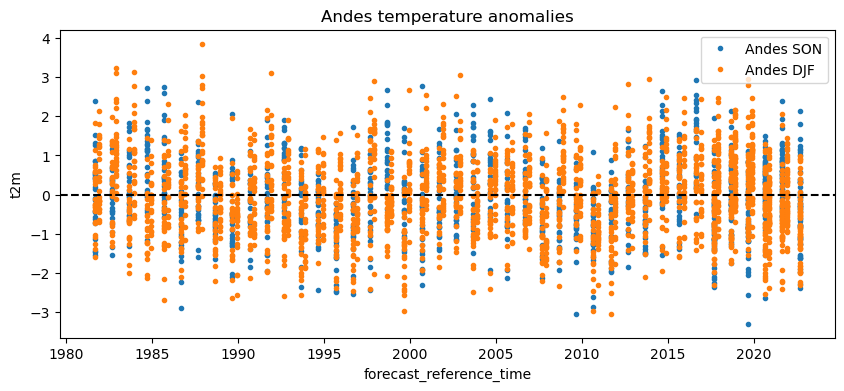

In [26]:
plt.figure(figsize=(10, 4))

t_Andes_ssavg_SON["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes SON"
)

t_Andes_ssavg_DJF["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("Andes temperature anomalies")
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))

t_LaPlata_ssavg_SON["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata SON"
)

t_LaPlata_ssavg_DJF["t2m"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("La Plata temperature anomalies")
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))

pr_era_Andes_ssavg_SON["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes SON"
)

pr_era_Andes_ssavg_DJF["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="Andes DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("Andes precipitation-rate anomalies")
plt.show()

In [ ]:
plt.figure(figsize=(10, 4))

pr_era_LaPlata_ssavg_SON["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata SON"
)

pr_era_LaPlata_ssavg_DJF["tprate"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none",
    label="La Plata DJF"
)

plt.axhline(0, color="black", linestyle="dashed")
plt.legend()
plt.title("La Plata precipitation-rate anomalies")
plt.show()

In [ ]:
pr_era_Andes_ssavg_SON = pr_era_Andes_ssavg_SON.rename({"tprate": "tp"})
pr_era_Andes_ssavg_DJF = pr_era_Andes_ssavg_DJF.rename({"tprate": "tp"})
pr_era_LaPlata_ssavg_SON = pr_era_LaPlata_ssavg_SON.rename({"tprate": "tp"})
pr_era_LaPlata_ssavg_DJF = pr_era_LaPlata_ssavg_DJF.rename({"tprate": "tp"})

In [ ]:
pr_era_Andes_ssavg_DJF["tp"].plot(
    x="forecast_reference_time",
    marker=".",
    linestyle="none"
)
plt.axhline(0, color="black", linestyle="dashed")
plt.show()

SEAS5 Hindcast Temperature and Precipitation data

In [ ]:
#load temperature era5 data
t_era=xr.open_dataset('/climca/data/SEAS5_SA/data/seas5_single_levels.nc').t2m  #variable name is t2m
t_era=t_era.rename({'forecast_reference_time':'time','latitude':'lat','longitude':'lon'})
t_Andes=t_era.sel(time=slice('1981','2022'),lat=slice(-35,-55),lon=slice(284,290)) 
t_LaPlata=t_era.sel(time=slice('1981','2022'),lat=slice(-20,-32),lon=slice(298,311))
display(t_LaPlata)

#compute anomaly 
t_Andes_an=compute_anomaly(t_Andes)
t_LaPlata_an=compute_anomaly(t_LaPlata)

#detrending
p_tAndes = t_Andes_an.sel(number=0).polyfit(dim='valid_time', deg=1, skipna=False)
t_fit = xr.polyval(t_Andes_an['time'], p_tAndes.t2m_polyfit_coefficients)
t_Andes_detr=t_Andes_an - t_fit

p_tLaPlata = t_LaPlata_an.polyfit(dim='time', deg=1, skipna=False)
fit = xr.polyval(t_LaPlata_an['time'], p_tLaPlata.t2m_polyfit_coefficients)
t_LaPlata_detr=t_LaPlata_an - fit

#weight by lat
t_Andes_wght=weight_by_latitude(t_Andes_detr)
t_LaPlata_wght=weight_by_latitude(t_LaPlata_detr)

#area averaging and normalising
t_Andes_avg=t_Andes_wght.mean(dim=['lat','lon'])/t_Andes_wght.mean(dim=['lat','lon']).std()
t_LaPlata_avg=t_LaPlata_wght.mean(dim=['lat','lon'])/t_LaPlata_wght.mean(dim=['lat','lon']).std()

t_Andes_avg['t2m'].plot(label='Andes')
t_LaPlata_avg['t2m'].plot(label='La Plata')
plt.legend()
plt.show()
#extract seasonal data
t_Andes_DJF=extract_seasonal_data(t_Andes_avg,[12,1,2])
t_Andes_SON=extract_seasonal_data(t_Andes_avg,[9,10,11])
t_LaPlata_DJF=extract_seasonal_data(t_LaPlata_avg,[12,1,2])
t_LaPlata_SON=extract_seasonal_data(t_LaPlata_avg,[9,10,11])
#average seasonally and standardise again
t_Andes_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(t_Andes_DJF)))
t_Andes_ssavg_SON=stdize_ssavg(seasonal_average(t_Andes_SON))
t_LaPlata_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(t_LaPlata_DJF)))
t_LaPlata_ssavg_SON=stdize_ssavg(seasonal_average(t_LaPlata_SON))

t_Andes_ssavg_DJF['t2m'].plot(label='DJF')
t_Andes_ssavg_SON['t2m'].plot(label='SON')
plt.hlines(np.mean(t_Andes_ssavg_DJF['t2m']),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.hlines(np.mean(t_Andes_ssavg_SON['t2m']),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.show()
t_LaPlata_ssavg_DJF['t2m'].plot(label='DJF')
plt.hlines(np.mean(t_LaPlata_ssavg_DJF['t2m']),xmin=1950, xmax=2025, color='red', linestyle='dashed')
t_LaPlata_ssavg_SON['t2m'].plot(label='SON')
plt.show()
#load precip era5 data --> tp=total precipitation
pr_era=xr.open_dataset('data/era5_tp.nc').tprate
pr_era=pr_era.rename({'valid_time':'time','latitude':'lat','longitude':'lon'})
#select time frame and regions
pr_Andes=pr_era.sel(time=slice('1981','2022'),lat=slice(-35,-55),lon=slice(-76,-70)) 
pr_LaPlata=pr_era.sel(time=slice('1981','2022'),lat=slice(-20,-32),lon=slice(-62,-49))
#anomaly
pr_Andes_an=compute_anomaly(pr_Andes)
pr_LaPlata_an=compute_anomaly(pr_LaPlata)

#detrend
p_prAndes = pr_Andes_an.polyfit(dim='time', deg=1, skipna=False)
pr_fit = xr.polyval(pr_Andes_an['time'], p_prAndes.tp_polyfit_coefficients)
pr_Andes_detr=pr_Andes_an - pr_fit

p_prLaPlata = pr_LaPlata_an.polyfit(dim='time', deg=1, skipna=False)
fit = xr.polyval(pr_LaPlata_an['time'], p_prLaPlata.tp_polyfit_coefficients)
pr_LaPlata_detr=pr_LaPlata_an - fit
#display(pr_Andes_detr)

#weight by lat
pr_Andes_wght=weight_by_latitude(pr_Andes_detr)
pr_LaPlata_wght=weight_by_latitude(pr_LaPlata_detr)

#area avg and normalising
pr_Andes_avg=pr_Andes_wght.mean(dim=['lat','lon'])/pr_Andes_wght.mean(dim=['lat','lon']).std()
pr_LaPlata_avg=pr_LaPlata_wght.mean(dim=['lat','lon'])/pr_LaPlata_wght.mean(dim=['lat','lon']).std()

pr_Andes_avg['tp'].plot(label='Andes')
pr_LaPlata_avg['tp'].plot(label='La Plata')
plt.show()

#extract seasonal data
pr_era_Andes_DJF=extract_seasonal_data(pr_Andes_avg,[12,1,2])
pr_era_Andes_SON=extract_seasonal_data(pr_Andes_avg,[9,10,11])
pr_era_LaPlata_DJF=extract_seasonal_data(pr_LaPlata_avg,[12,1,2])
pr_era_LaPlata_SON=extract_seasonal_data(pr_LaPlata_avg,[9,10,11])

#seasonal avg & seasonal standardising
pr_era_Andes_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(pr_era_Andes_DJF)))
pr_era_Andes_ssavg_SON=stdize_ssavg(seasonal_average(pr_era_Andes_SON))
pr_era_LaPlata_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(pr_era_LaPlata_DJF)))
pr_era_LaPlata_ssavg_SON=stdize_ssavg(seasonal_average(pr_era_LaPlata_SON))



pr_era_Andes_ssavg_DJF['tp'].plot()
pr_era_Andes_ssavg_SON['tp'].plot()
plt.hlines(np.mean(pr_era_Andes_ssavg_DJF['tp']),xmin=1981, xmax=2022, color='red', linestyle='dashed')
plt.show()
pr_era_LaPlata_ssavg_DJF['tp'].plot()
plt.hlines(np.mean(pr_era_LaPlata_ssavg_DJF['tp']),xmin=1981, xmax=2022, color='red', linestyle='dashed')
pr_era_LaPlata_ssavg_SON['tp'].plot()
plt.show()

<xarray.DataArray 't2m' (number: 51, time: 250, forecastMonth: 6, lat: 13,
                         lon: 14)> Size: 56MB
[13923000 values with dtype=float32]
Coordinates:
  * number         (number) int64 408B 0 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
  * time           (time) datetime64[ns] 2kB 1981-01-01 ... 2022-10-01
  * forecastMonth  (forecastMonth) int64 48B 1 2 3 4 5 6
  * lat            (lat) float64 104B -20.0 -21.0 -22.0 ... -30.0 -31.0 -32.0
  * lon            (lon) float64 112B 298.0 299.0 300.0 ... 309.0 310.0 311.0
Attributes: (12/33)
    GRIB_paramId:                             167
    GRIB_dataType:                            fcmean
    GRIB_numberOfPoints:                      65160
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [ ]:
print(t_Andes_ssavg_DJF['t2m'])
#looking for the nans :)
#display(tas_LaPlata['tas'].dropna(dim='time'))
#display(tas_LaPlata['tas'].isnull().any())
#nan_locations = tas_LaPlata.where(tas_LaPlata.isnull(), drop=True)
#print(nan_locations)

<xarray.DataArray 't2m' (year: 76)>
array([-1.6022509 , -1.79131542,  0.56137977, -0.26167945, -1.20955315,
       -1.49955036, -2.22824338,  0.61426181,  0.14821509, -0.41487018,
        1.88295753, -0.56991681,  0.73479557,  1.08235173,  0.21110418,
        0.53671439, -1.39830169, -0.62812498,  0.34088132, -0.32863548,
        0.5753784 , -2.42153142, -1.0663637 , -0.12649841, -1.22427195,
        0.46748456, -1.81054311, -0.37198573,  1.7245314 ,  1.83777078,
        1.33596842,  0.10673814,  0.55391553,  1.32872721,  1.07293155,
        1.42620363, -0.56455381,  0.81111426,  0.48836499,  0.41065496,
        0.59153105, -0.36006196, -0.9768878 ,  0.3827813 , -0.04174155,
        0.17247628, -0.23019913, -1.18401277,  0.39102731,  0.38549629,
       -0.85937089, -1.59829492,  0.42191427, -0.8313529 ,  0.48484346,
        0.98522061,  0.59737548, -1.2177421 ,  1.46010567,  1.20157915,
       -2.24998969, -0.93281886,  0.85696763,  0.7543791 , -0.46403309,
       -0.14401616,  0.65496

Filter function

In [ ]:
from scipy.signal import butter, filtfilt

# Function to apply a low-pass filter (removes >7-year variations)

def lowpass_filter(da, cutoff=1/7, fs=12):
    nyq=fs/2
    wn=cutoff/nyq #standardising my input frequency with nyquist
    # Design the Butterworth filter
    b, a = butter(N=6, Wn=wn, btype='high', fs=fs) 
    #actually it is high pass because low frequency signal acts on long timescales

    # Define a function to apply the filter on 1D time series
    def filter_1d(x):
        if np.any(np.isnan(x)):  # Handle NaNs
            x = np.nan_to_num(x, nan=np.nanmean(x))  # Replace NaNs with mean
        return filtfilt(b, a, x)

    # Apply the filter along the 'time' dimension
    filtered_da = xr.apply_ufunc(
        filter_1d, 
        da, 
        input_core_dims=[["time"]],  # Apply only along 'time'
        output_core_dims=[["time"]],
        vectorize=True  # Ensures it works for each lat/lon point
    )

    return filtered_da

# Function to apply a 3-month running mean
def running_mean(da, window=3):
    return da.rolling(time=window, center=True).mean()

IOD and ENSO

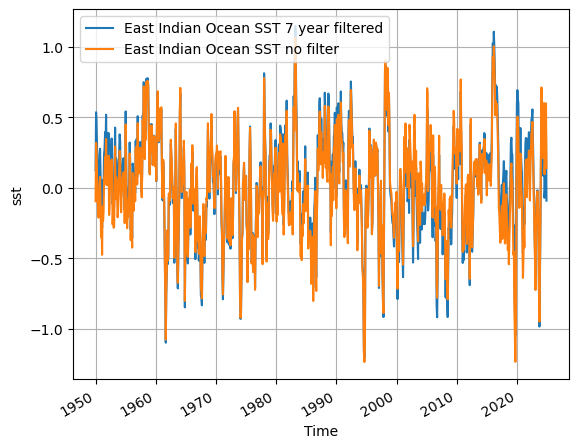

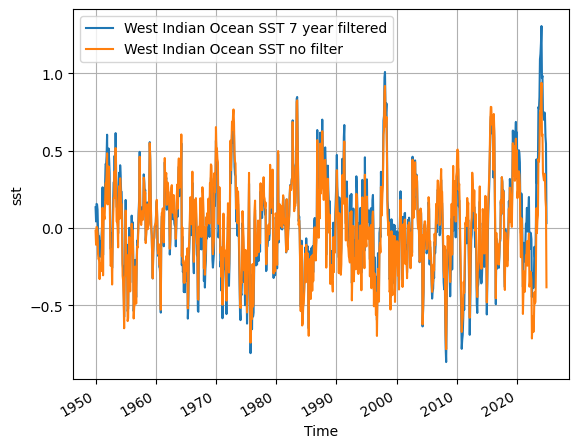

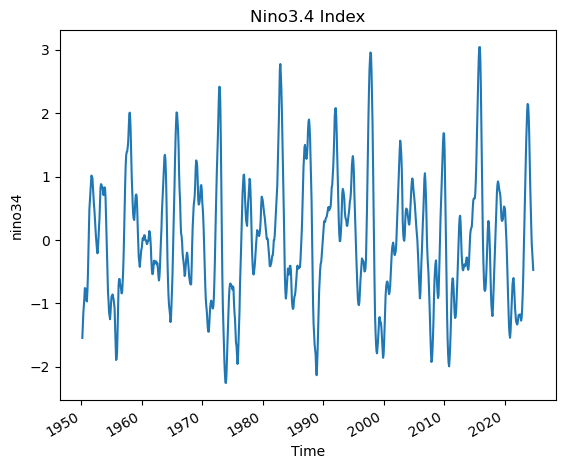

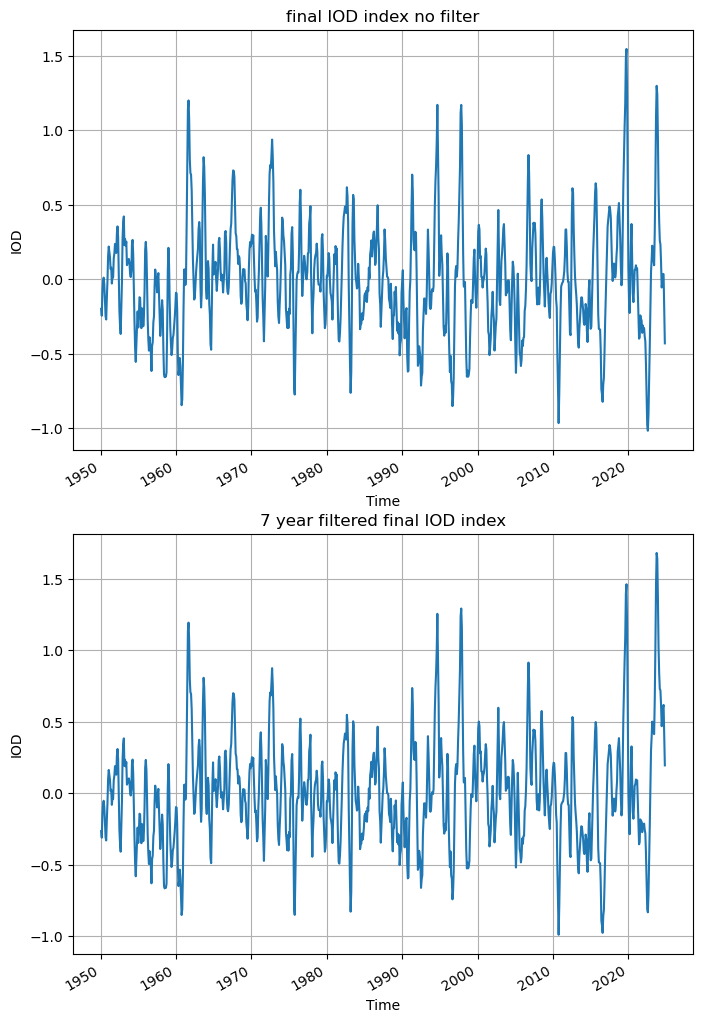

C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can b

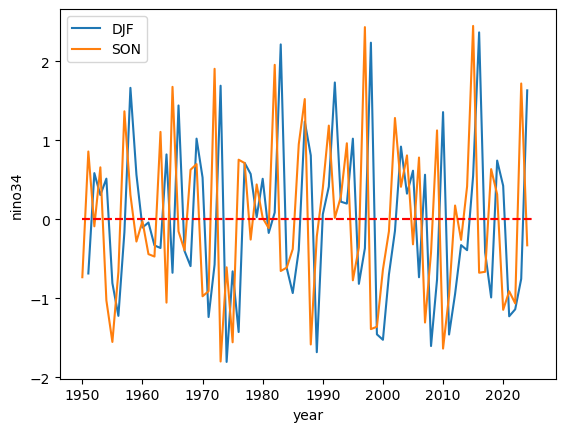

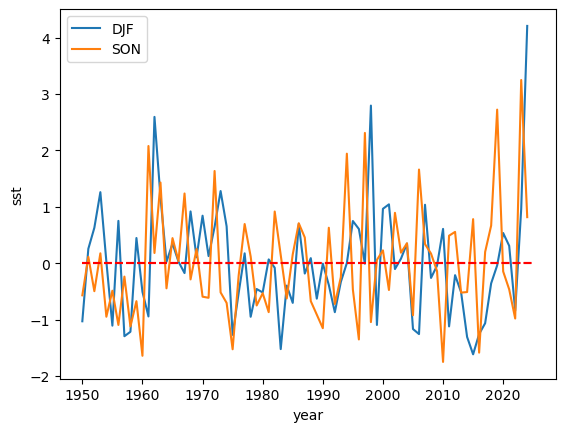

In [ ]:

### Sea surface temperature, already monthly data
sst = xr.open_dataset('data/sst.mnmean.nc')
#display(sst)

#weighting by latitude
sst_sliceweighted_nino=sst.sel(time=slice('1950','2024'),lat=slice(5,-5),lon=slice(190,240))

sst_io_eastweighted=sst.sel(time=slice('1950','2024'),lat=slice(0,-10),lon=slice(90,110))
sst_io_westweighted=sst.sel(time=slice('1950','2024'),lat=slice(10,-10),lon=slice(50,70))

#what is my reference period of climatology? --> whole time period
sst_climatology_nino=sst_sliceweighted_nino.groupby('time.month').mean('time')

sst_climatology_ioe=sst_io_eastweighted.groupby('time.month').mean('time') #east io climate avg
sst_climatology_iow=sst_io_westweighted.groupby('time.month').mean('time') # west io climate avg

#compute anomaly and average for every grid point
sst_anomaly_nino=sst_sliceweighted_nino.groupby('time.month')-sst_climatology_nino
sst_anomaly_nino_weighted=weight_by_latitude(sst_anomaly_nino)
nino_index=sst_anomaly_nino_weighted.mean(dim=['lat','lon'])

sst_anomaly_ioe=weight_by_latitude(sst_io_eastweighted.groupby('time.month')-sst_climatology_ioe)
sst_anomaly_iow=weight_by_latitude(sst_io_westweighted.groupby('time.month')-sst_climatology_iow)
ioe_mean=sst_anomaly_ioe.mean(dim=['lon','lat'])
iow_mean=sst_anomaly_iow.mean(dim=['lon', 'lat'])

#detrend
p_nino=nino_index.polyfit(dim='time', deg=1, skipna=False)
nino_fit=xr.polyval(nino_index['time'], p_nino.sst_polyfit_coefficients)
nino_detr=nino_index-nino_fit

p_ioe=ioe_mean.polyfit(dim='time', deg=1, skipna=False)
ioe_fit=xr.polyval(ioe_mean['time'],p_ioe.sst_polyfit_coefficients)
ioe_detr=ioe_mean-ioe_fit

p_iow=iow_mean.polyfit(dim='time', deg=1, skipna=False)
iow_fit=xr.polyval(iow_mean['time'],p_iow.sst_polyfit_coefficients)
iow_detr=iow_mean-iow_fit

#removing the interdecadal 7 year trend
ioe_filtered=lowpass_filter(ioe_detr['sst'])
iow_filtered=lowpass_filter(iow_detr['sst'])
ioe_filtered.plot(label='East Indian Ocean SST 7 year filtered') 
ioe_detr['sst'].plot(label='East Indian Ocean SST no filter')
plt.legend()
plt.grid()
plt.savefig('East_Indian_Ocean_SST.pdf', bbox_inches='tight')
plt.show()
iow_filtered.plot(label='West Indian Ocean SST 7 year filtered')
iow_detr['sst'].plot(label='West Indian Ocean SST no filter')
plt.legend()
plt.grid()
plt.savefig('West_Indian_Ocean_SST.pdf', bbox_inches='tight')
plt.show()

#compute 5 month average (ENSO) and 3 month average (IOD)
sst_anomaly_smoothed = nino_detr.rolling(time=5, center=True).mean()

iode_smoothed=ioe_detr.rolling(time=3, center=True).mean()
iodw_smoothed=iow_detr.rolling(time=3, center=True).mean()
iod_index=iodw_smoothed-iode_smoothed

# normalise index
std=sst_anomaly_smoothed.std(dim='time')
nino34_index = sst_anomaly_smoothed/std
nino34_index=nino34_index.rename({'sst':'nino34'})
nino34_index['nino34'].sel(time=slice('1950','2024')).plot() #looking good compared to other time series of el nino :)
plt.title('Nino3.4 Index')
plt.show()

iod_index=iod_index.rename({'sst':'IOD'})
iod_index_with_filter=(iow_filtered.rolling(time=3, center=True).mean()-ioe_filtered.rolling(time=3, center=True).mean())

#plotting
plt.figure(figsize=(8,12))
plt.subplot(211) #2 rows 1 column and 1st plot/index
iod_index['IOD'].sel(time=slice('1950','2024')).plot()
plt.title('final IOD index no filter')
plt.grid()
plt.subplot(212)
iod_index_with_filter.plot()
plt.title('7 year filtered final IOD index')
plt.ylabel('IOD')
plt.grid()
plt.savefig('IOD_index.pdf', bbox_inches='tight')
plt.show()

#extract seasonal data
nino34_index_SON=extract_seasonal_data(nino34_index,[9,10,11])
nino34_index_DJF=extract_seasonal_data(nino34_index,[12,1,2])

iod_index_SON=extract_seasonal_data(iod_index_with_filter,[9,10,11])
iod_index_DJF=extract_seasonal_data(iod_index_with_filter,[12,1,2])

iod_nino_list=[nino34_index_DJF, nino34_index_SON, iod_index_DJF, iod_index_SON]
iod_nino_list_upd=[]
for item in iod_nino_list:
    item=stdize_ssavg(seasonal_average(shift_december(item)))
    iod_nino_list_upd.append(item)
#iod_nino_list[0]['nino34'].plot()
iod_nino_list_upd[0]['nino34'].plot(label='DJF')
plt.hlines(np.mean(iod_nino_list_upd[0]['nino34']),xmin=1950, xmax=2025, color='red', linestyle='dashed')
iod_nino_list_upd[1]['nino34'].plot(label='SON')
plt.hlines(np.mean(iod_nino_list_upd[1]['nino34']),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.legend()
plt.show()
iod_nino_list_upd[2].plot(label='DJF')
plt.hlines(np.mean(iod_nino_list_upd[2]),xmin=1950, xmax=2025, color='red', linestyle='dashed')
iod_nino_list_upd[3].plot(label='SON')
plt.hlines(np.mean(iod_nino_list_upd[3]),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.legend()
plt.show()

In [ ]:
sst['time']

<xarray.DataArray 'time' (time: 2053)>
array(['1854-01-01T00:00:00.000000000', '1854-02-01T00:00:00.000000000',
       '1854-03-01T00:00:00.000000000', ..., '2024-11-01T00:00:00.000000000',
       '2024-12-01T00:00:00.000000000', '2025-01-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2025-01-01
Attributes:
    long_name:        Time
    delta_t:          0000-01-00 00:00:00
    avg_period:       0000-01-00 00:00:00
    prev_avg_period:  0000-00-07 00:00:00
    standard_name:    time
    axis:             T
    actual_range:     [19723. 82180.]

Trying out different filter orders

In [ ]:
#looking at the filter in detail
ioe_detr2=ioe_detr.drop(['time', 'time_bnds'])
ioe_detr2=ioe_detr2.to_array().T

N=np.arange(1,10,1)
w_list=[]
h_list=[]
c_list=[]
freqs_filt_list=[]
spectrum_filt_list=[]
removal_list=[]
# Compute Fourier Transform of original and filtered signals
def compute_spectrum(signal, fs):
    N = len(signal)  # Number of samples
    fft_values = np.fft.fft(signal)  # Compute FFT
    freqs = np.fft.fftfreq(N, d=1/fs)  # Frequency axis (cycles per year)
    
    return freqs[:N//2], np.abs(fft_values[:N//2])  # Return positive frequencies
 

# Compute spectra
freqs_orig, spectrum_orig = compute_spectrum(ioe_detr['sst'], 12)
#freqs_filt, spectrum_filt = compute_spectrum(c_list[0], fs)
for n in N:
    fs=12
    nyqf=fs/2
    wn=1/7/nyqf
    b,a =butter(N=n, Wn=wn, btype='high', fs=fs)
    w,h=signal.freqs(b,a)
    w_list.append(w)
    h_list.append(h)
    c=filtfilt(b,a, ioe_detr['sst'])
    c_list.append(c)
    freqs_filt_list.append(compute_spectrum(c,fs)[0])
    spectrum_filt_list.append(compute_spectrum(c,fs)[1])
    
    removal=ioe_detr2.T-c
    removal_list.append(removal.T)
#for y axis scaling
h_min, h_max = np.min([np.min(h) for h in h_list]), np.max([np.max(h) for h in h_list])
c_min, c_max = np.min([np.min(c) for c in c_list]), np.max([np.max(c) for c in c_list])
spec_min=np.min([np.min(c) for c in spectrum_filt_list])
spec_max=[np.max(c) for c in spectrum_filt_list]
#print(spectrum_orig)
removal_min=[np.min(h) for h in removal_list]
removal_max=[np.max(h) for h in removal_list]
print(removal_list[0], removal_min[0], removal_max[0])

<xarray.DataArray (time: 900, variable: 1)>
array([[ 1.37610408e-02],
       [ 1.38795443e-02],
       [ 1.39693604e-02],
       [ 1.40269031e-02],
       [ 1.40751546e-02],
       [ 1.41350374e-02],
       [ 1.42190221e-02],
       [ 1.43314018e-02],
       [ 1.44622292e-02],
       [ 1.45943472e-02],
       [ 1.47259286e-02],
       [ 1.48795420e-02],
       [ 1.50757696e-02],
       [ 1.53232642e-02],
       [ 1.56236433e-02],
       [ 1.59644222e-02],
       [ 1.63378605e-02],
       [ 1.67342328e-02],
       [ 1.71316616e-02],
       [ 1.75132459e-02],
...
       [-5.41215406e-02],
       [-5.45400111e-02],
       [-5.49589273e-02],
       [-5.53680337e-02],
       [-5.57350273e-02],
       [-5.60094029e-02],
       [-5.61689657e-02],
       [-5.62480310e-02],
       [-5.63081285e-02],
       [-5.64164839e-02],
       [-5.66084739e-02],
       [-5.68719500e-02],
       [-5.71929569e-02],
       [-5.75681203e-02],
       [-5.80108689e-02],
       [-5.85267157e-02],
       [-5.90892

C:\Users\giuli\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\giuli\anaconda3\Lib\site-packages\numpy\ma\core.py:3375: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
C:\Users\giuli\anaconda3\Lib\site-packages\matplotlib\transforms.py:2868: ComplexWarning: Casting complex values to real discards the imaginary part
  vmin, vmax = map(float, [vmin, vmax])
C:\Users\giuli\anaconda3\Lib\site-packages\matplotlib\cbook\__init__.py:1340: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
C:\Users\giuli\anaconda3\Lib\site-packages\numpy\ma\core.py:3375: ComplexWarning: Casting complex values to real discards the imaginary part
  _data[indx] = dval
C:\Users\giuli\anaconda3\Lib\site-packages\matplotlib\transforms.py:2868: ComplexWarning: Casting complex values to real 

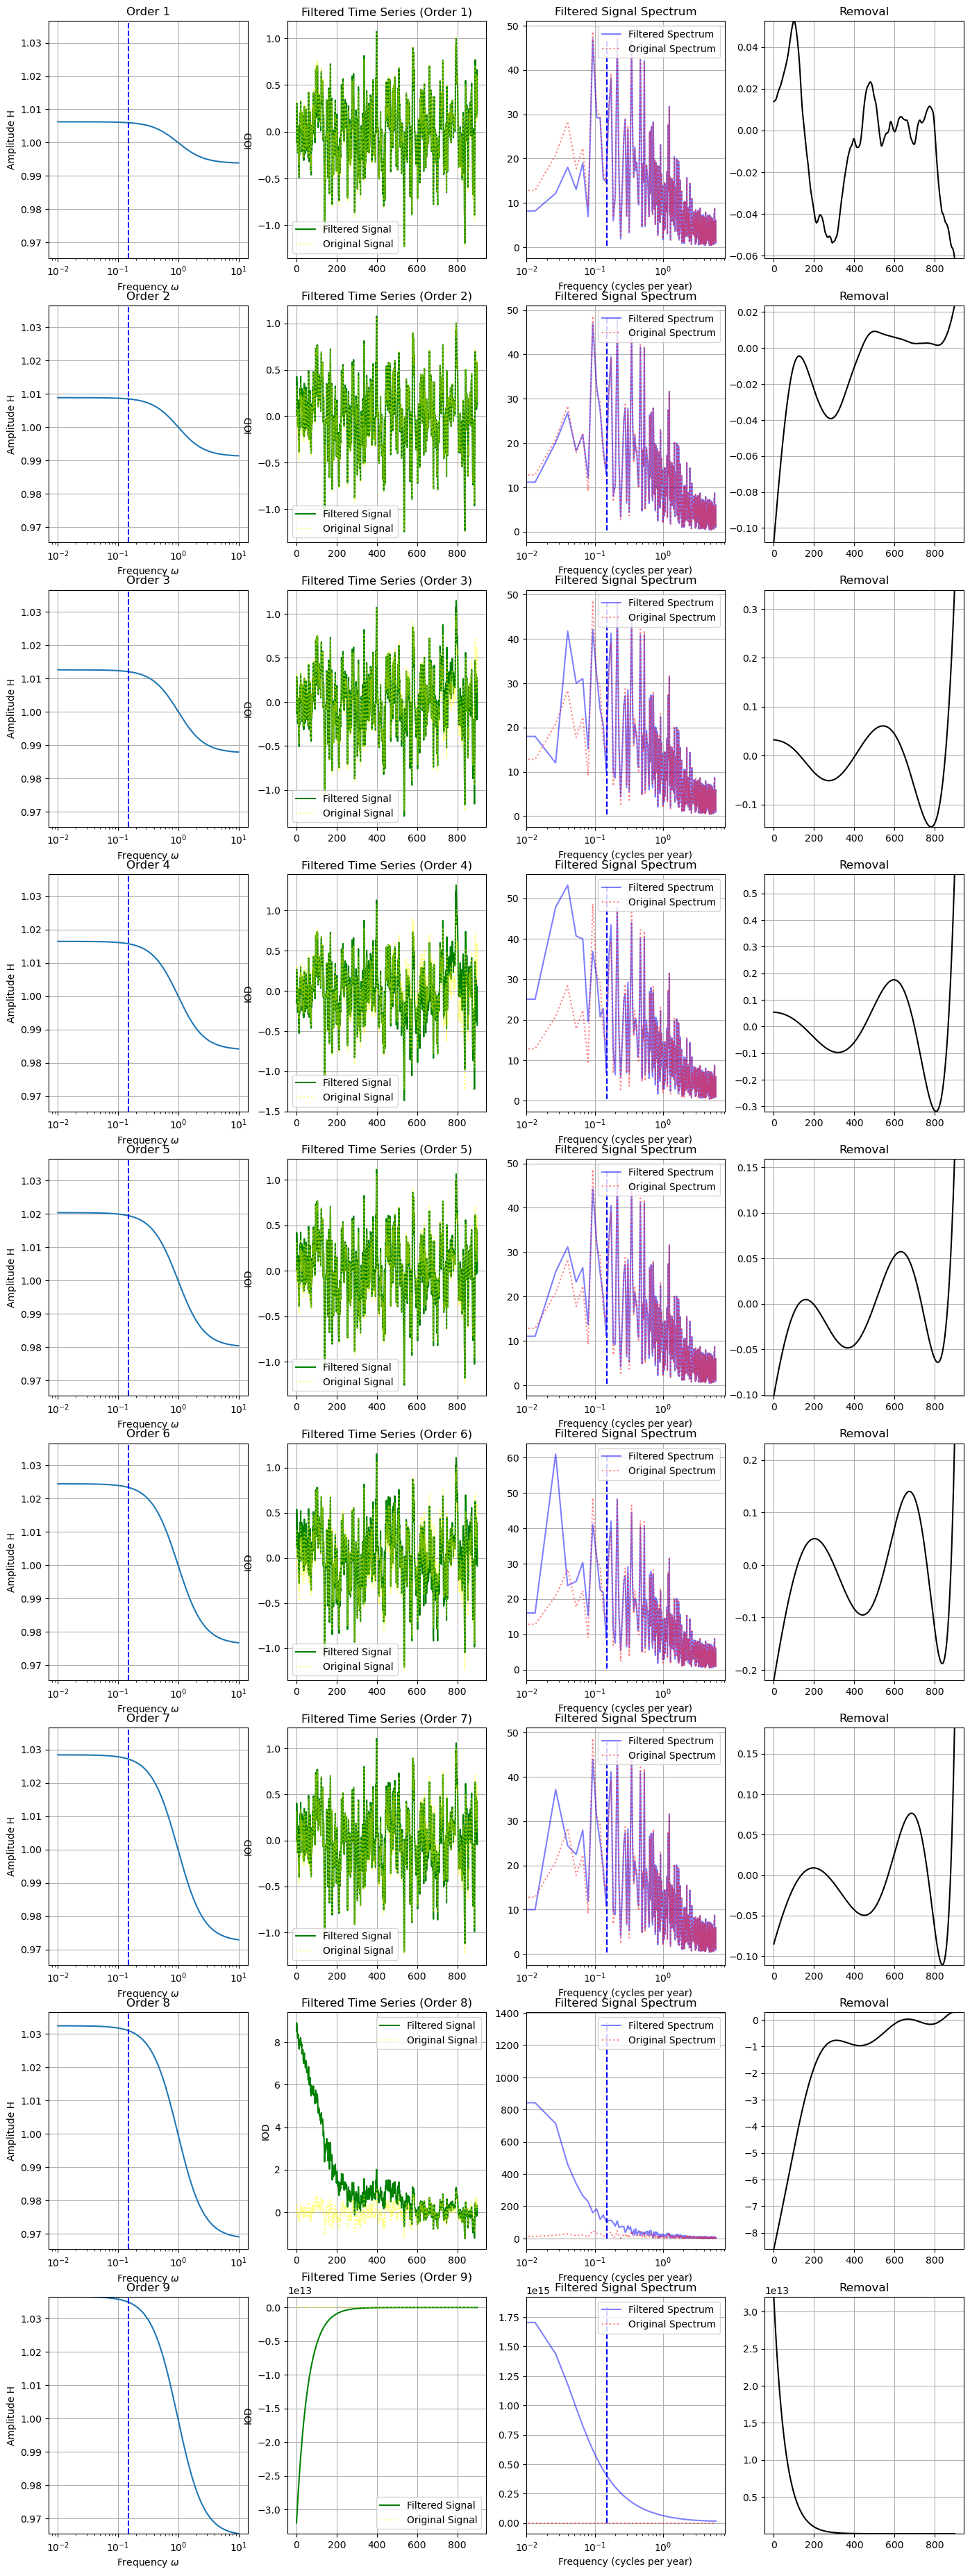

In [ ]:
# Create subplots grid
fig, axes = plt.subplots(nrows=len(w_list), ncols=4, figsize=(17, 47))
for i in range(len(w_list)):
    # Frequency response subplot (left side)
    ax1 = axes[i, 0] if len(w_list) > 1 else axes[0]  # Adjust for single-row case
    ax1.semilogx(w_list[i], h_list[i])
    ax1.vlines(x=0.149, ymin=np.min(h_min), ymax=np.max(h_max), color='blue', linestyle='dashed')
    #ax1.vlines(x=0.179, ymin=np.min(h_min), ymax=np.max(h_max), color='red', linestyle='dotted')
    #ax1.vlines(x=0.119, ymin=np.min(h_min), ymax=np.max(h_max), color='red', linestyle='dotted')
    ax1.set_title(f'Order {i+1}')
    ax1.set_ylim(h_min, h_max) 
    ax1.set_xlabel('Frequency $\omega$')
    ax1.set_ylabel('Amplitude H')
    ax1.grid(True)

    # Time series subplot (right side)
    ax2 = axes[i, 1] if len(w_list) > 1 else axes[1]  # Adjust for single-row case
    ax2.plot(c_list[i], label='Filtered Signal', color='green')
    ax2.plot(ioe_detr2, label='Original Signal', color='yellow', linestyle='dotted', alpha=0.5)
    ax2.set_title(f'Filtered Time Series (Order {i+1})')
    ax2.set_ylabel('IOD')
    #ax2.set_ylim(c_min, c_max) 
    ax2.legend()
    ax2.grid(True)
    
    # Spectrum of filtered signal
    ax3=axes[i,2] if len(w_list) > 1 else axes[1]
    ax3.semilogx(freqs_filt_list[i], spectrum_filt_list[i], label="Filtered Spectrum", color='blue', alpha=0.5)
    ax3.semilogx(freqs_orig, spectrum_orig, label="Original Spectrum", color='red', linestyle='dotted', alpha=0.5)
    ax3.vlines(x=0.149, ymin=spec_min, ymax=spec_max[i], color='blue', linestyle='dashed')
    ax3.set_title("Filtered Signal Spectrum")
    ax3.legend()
    ax3.set_xlabel("Frequency (cycles per year)")
    ax3.grid(True)
    
    #Removed signal
    ax4=axes[i,3] if len(w_list) > 1 else axes[3]
    ax4.plot(removal_list[i], label='Removed Part of Signal', color='black')
    ax4.set_title('Removal')
    ax4.set_ylim(removal_min[i], removal_max[i])
    ax4.grid(True)
# Adjust layout for better spacing
#plt.tight_layout()
plt.savefig('Butterworth_filters.pdf', bbox_inches='tight')
plt.show()
#print(h_max)

#following computations from ipad my order should be 6


SPV and EDJ

C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can b

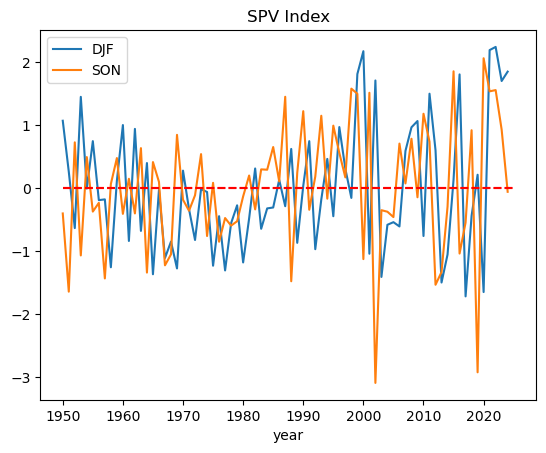

C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can b

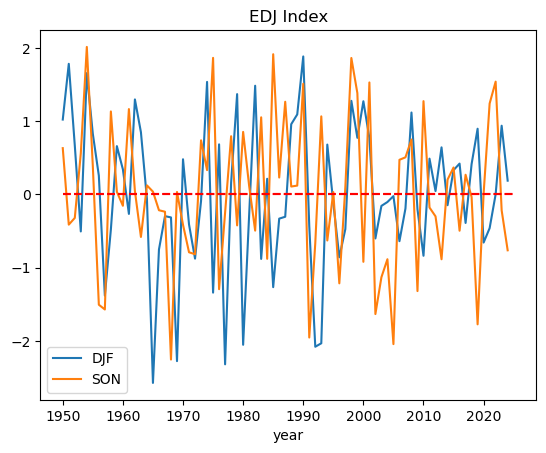

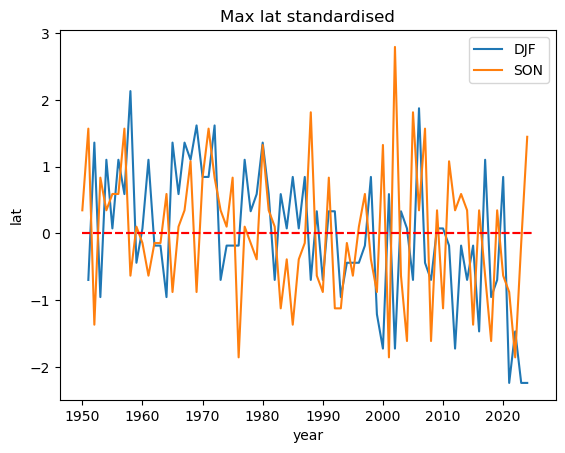

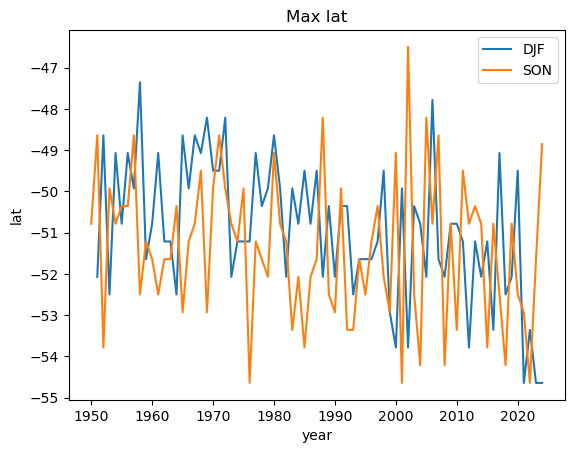

In [ ]:

### Stratospheric zonal winds
ua = xr.open_dataset('data/era5_ua_2.5x2.5.nc')
ua = ua.rename({'valid_time': 'time'})
#display(ua)
# polar vortex following kretschmer which follows byrne 2019
polar_vortex =  ua.sel(pressure_level=50).drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-65,-55))

#compute anomaly (#climatologicl mean!!!), weight by lat and average for every gridpoint
polar_vortex_an=weight_by_latitude(compute_anomaly(polar_vortex))
polar_vortex_an_avg=polar_vortex_an['u'].mean(dim=['lat','lon'])

#detrend
p_vortex=polar_vortex_an_avg.polyfit(dim='time', deg=1, skipna=False)
vortex_fit=xr.polyval(nino_index['time'], p_vortex.polyfit_coefficients)
vortex_detr=polar_vortex_an_avg-vortex_fit

#smoothen
vortex_smoothed=vortex_detr.rolling(time=3, center=True).mean()

#normalise
SPV_index=vortex_smoothed/vortex_smoothed.std(dim='time')

#extract seasons
SPV_DJF=extract_seasonal_data(SPV_index, [12,1,2])
SPV_SON=extract_seasonal_data(SPV_index,[9,10,11])

#seasonal average and standardise again
SPV_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(SPV_DJF)))
SPV_ssavg_SON=stdize_ssavg(seasonal_average(SPV_SON))

SPV_ssavg_DJF.plot(label='DJF')
SPV_ssavg_SON.plot(label='SON')
plt.hlines(np.mean(SPV_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.hlines(np.mean(SPV_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.title('SPV Index')
plt.legend()
plt.show()
#display(polar_vortex)

#edj following byrne 2017
EDJ = ua.sel(pressure_level=850).u.drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-70,-35))
edj_zonal_avg=EDJ.mean(dim='lon')
#display(edj_zonal_avg)
#find latitude at time t where wind is strongest
max_lat=edj_zonal_avg.idxmax(dim='lat')
max_lat_smoothed=max_lat.rolling(time=5, center=True).mean()
# find corresponding wind speed for the max latitude
edj_max=edj_zonal_avg.sel(lat=max_lat, method='nearest')

#compute anomaly
edj_max_an=compute_anomaly(edj_max)

#weight by lat
edj_max_wght=weight_by_latitude(edj_max_an)

#detrend
p_jet=edj_max_wght.polyfit(dim='time', deg=1, skipna=False)
jet_fit=xr.polyval(edj_max_wght['time'], p_jet.polyfit_coefficients)
edj_detr=edj_max_wght-jet_fit

#smoothen
edj_smooth=running_mean(edj_detr)

#normalise
edj_index=edj_smooth/edj_smooth.std(dim='time')
#display(edj_index)
#extract seasonal data
max_lat_DJF=extract_seasonal_data(max_lat_smoothed,[12,1,2])
max_lat_SON=extract_seasonal_data(max_lat_smoothed,[9,10,11])

edj_index_DJF=extract_seasonal_data(edj_index,[12,1,2])
edj_index_SON=extract_seasonal_data(edj_index,[9,10,11])

#seasonal average and standardise again
#edj speed
edj_index_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(edj_index_DJF)))
edj_index_ssavg_SON=stdize_ssavg(seasonal_average(edj_index_SON))
#max lat
max_lat_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(max_lat_DJF)))
max_lat_ssavg_SON=stdize_ssavg(seasonal_average(max_lat_SON))
max_lat_nostd_DJF=seasonal_average(shift_december(max_lat_DJF))
max_lat_nostd_SON=seasonal_average(max_lat_SON)

edj_index_ssavg_DJF.plot(label='DJF')
edj_index_ssavg_SON.plot(label='SON')
plt.hlines(np.mean(edj_index_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.hlines(np.mean(edj_index_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.legend()
plt.title('EDJ Index')
plt.show()
max_lat_ssavg_DJF.plot(label='DJF')
max_lat_ssavg_SON.plot(label='SON')
plt.hlines(np.mean(max_lat_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.hlines(np.mean(max_lat_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.legend()
plt.title('Max lat standardised')
plt.show()
max_lat_nostd_DJF.plot(label='DJF')
max_lat_nostd_SON.plot(label='SON')
plt.title('Max lat')
plt.legend()
plt.show()

In [ ]:
polar_vortex.u

plt.scatter(polar_vortex.time('month'==12), polar_vortex.u.mean(dim=['lat', 'lon']))

SAM

<xarray.Dataset>
Dimensions:         (valid_time: 1021, lon: 144, lat: 28, pressure_level: 2)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 1940-01-01 ... 2025-01-01
  * lon             (lon) float64 0.0 2.5 5.0 7.5 ... 350.0 352.5 355.0 357.5
  * lat             (lat) float64 -86.79 -80.36 -73.93 ... 73.93 80.36 86.79
  * pressure_level  (pressure_level) float64 500.0 50.0
Data variables:
    z               (valid_time, pressure_level, lat, lon) float32 ...
Attributes:
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Thu Feb 13 16:17:09 2025: cdo remapbil,r144x28 d...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

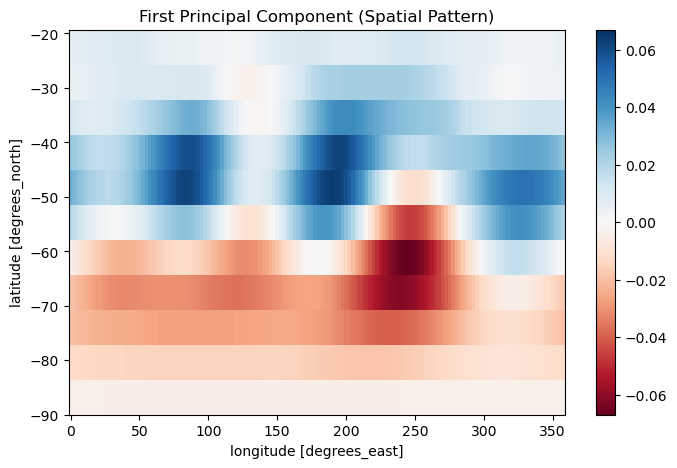

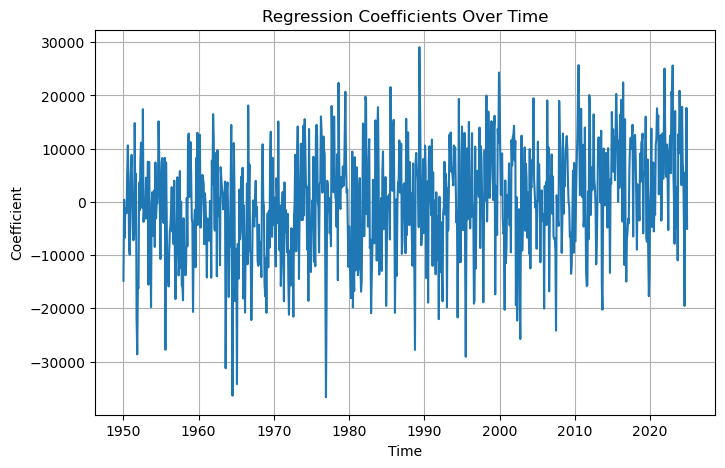

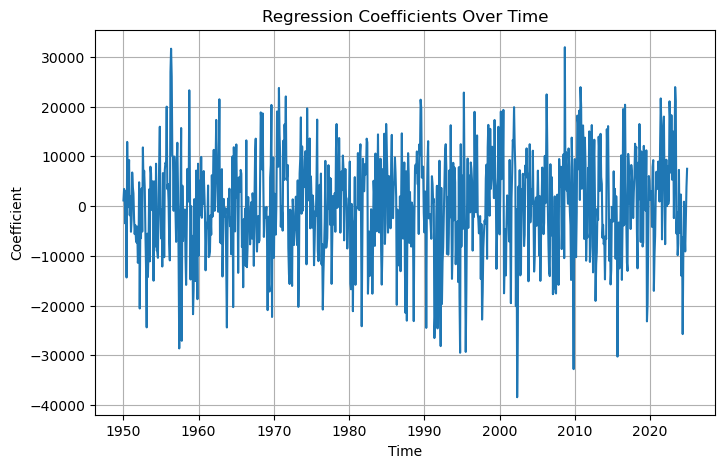

DJF


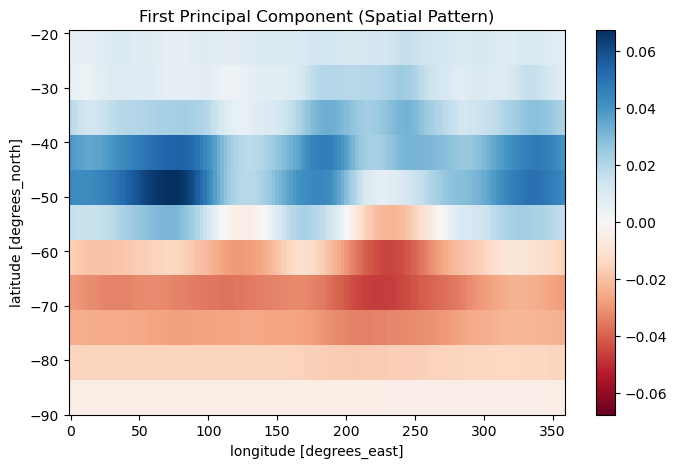

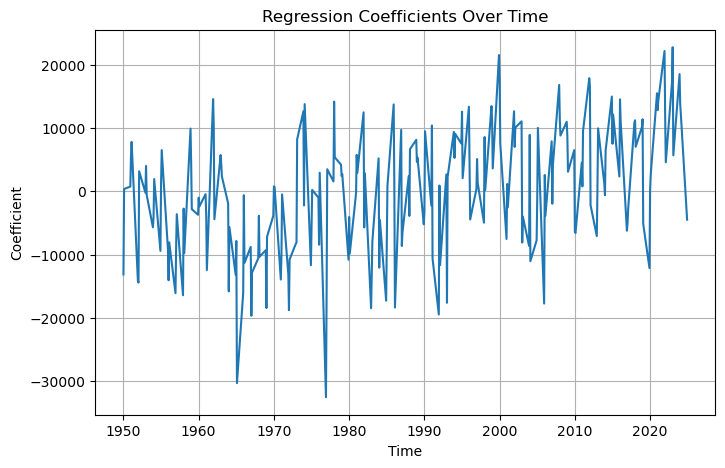

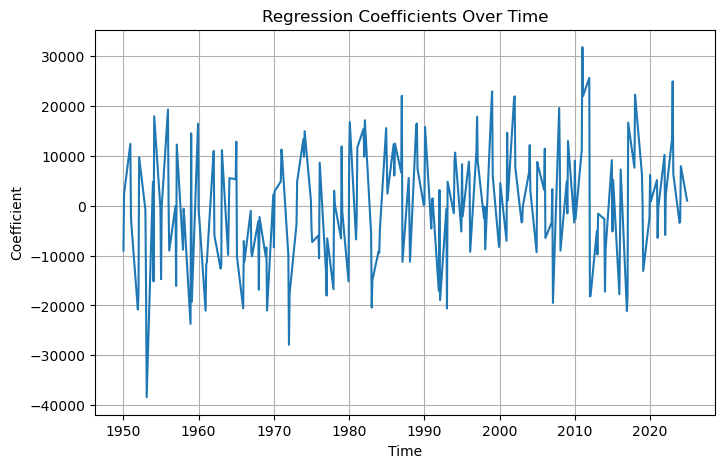

SON


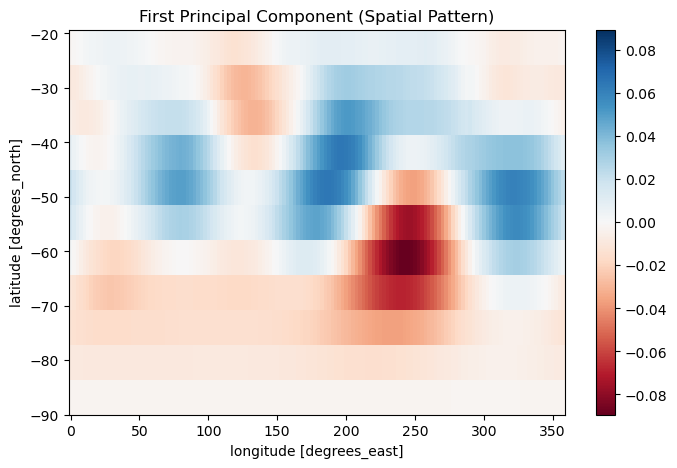

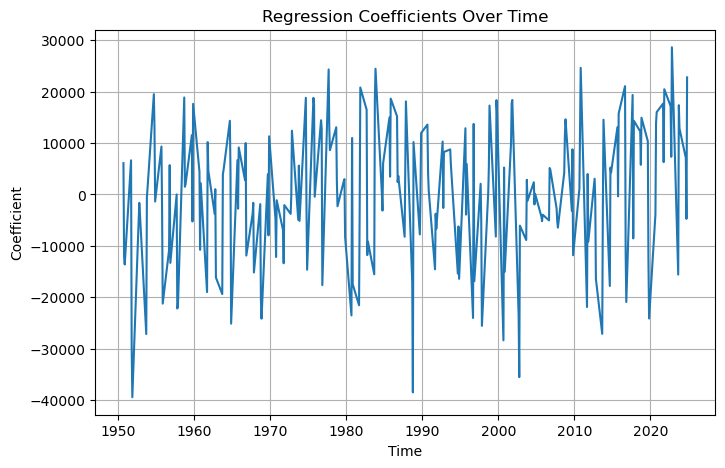

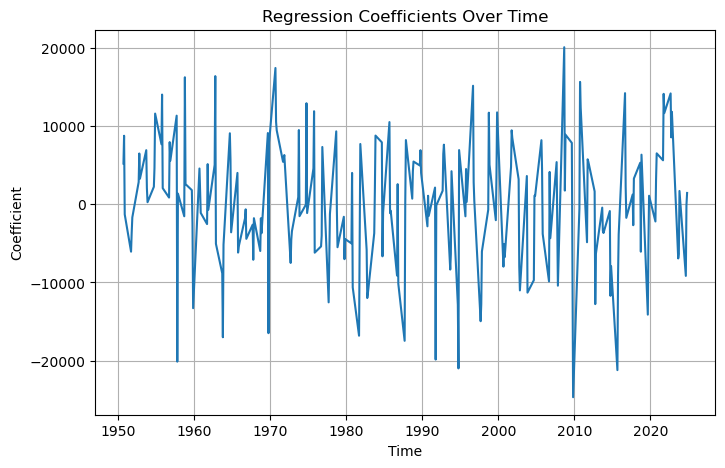

In [ ]:
### Geopotential height
zg = xr.open_dataset('data/era5_zg_2.5x2.5.nc')
display(zg)
zg = zg.rename({'valid_time': 'time'})
zg = zg.sel(pressure_level=500).z.drop('pressure_level').sel(time=slice('1950','2024'),lat=slice(-90,-20))
#display(zg['lat'])

# if one wants to look at it seasonally:
zg_DJF=extract_seasonal_data(zg,[12,1,2])
zg_SON=extract_seasonal_data(zg,[9,10,11])

# Compute monthly climatology --> each month has one average
zg_climatology = zg.groupby('time.month').mean('time')

# Compute monthly anomalies
zg_anomalies = zg.groupby('time.month') - zg_climatology
zg_anomalies_DJF=compute_anomaly(zg_DJF)
zg_anomalies_SON=compute_anomaly(zg_SON)

# Compute PCs
zg_weighted = weight_by_latitude(zg_anomalies)
reshaped_zg = reshape_to_2d(zg_weighted)

zg_weighted_DJF = weight_by_latitude(zg_anomalies_DJF)
reshaped_zg_DJF = reshape_to_2d(zg_weighted_DJF)
zg_weighted_SON = weight_by_latitude(zg_anomalies_SON)
reshaped_zg_SON = reshape_to_2d(zg_weighted_SON)

def SAM_procedure(reshaped_zg, zg_anomalies):
    cov_matrix = compute_covariance_matrix(reshaped_zg)
    U, S, Vt = perform_svd(cov_matrix) # all have shape 1584 in every dim, 
    #S has singular/eigenvalues and Vt has eigenvectors

    # Define SAM as first principal component
    SAM = plot_first_principal_component(reshaped_zg, Vt)

    # Decompose SAM in symmetric and asymmetric
    SAM_zonal_mean = compute_zonal_mean(SAM) #avg over all lon
    SAM_sym = make_zonal_mean_map(SAM_zonal_mean, zg_anomalies) #map the avg from above onto the whole field
    SAM_asym = SAM - SAM_sym #difference between map and first PCA gives 'anomaly'

    SAM_sym_coefficient = regress_onto_zonal_mean_map(zg_anomalies, SAM_sym)
    plot_regression_coefficients(zg_anomalies['time'], SAM_sym_coefficient)

    SAM_asym_coefficient = regress_onto_zonal_mean_map(zg_anomalies, SAM_asym)
    plot_regression_coefficients(zg_anomalies['time'], SAM_asym_coefficient)
    d={'SAM':SAM, 'SAM_zonal_mean':SAM_zonal_mean, 'SAM_sym':SAM_sym, 'SAM_asym':SAM_asym, \
       'SAM_sym_coefficient':SAM_sym_coefficient, 'SAM_asym_coefficient':SAM_asym_coefficient}
    return (d)

SAM_total=SAM_procedure(reshaped_zg, zg_anomalies)
SAM=SAM_total['SAM']
A_SAM_index=SAM_total['SAM_asym_coefficient']
S_SAM_index=SAM_total['SAM_sym_coefficient']

#weight by lat again? --> no
#detrend? --> no
A_SAM_detr=A_SAM_index
S_SAM_detr=S_SAM_index
#normalise
A_SAM_avg=(A_SAM_detr-A_SAM_detr.mean())/A_SAM_detr.std()
S_SAM_avg=(S_SAM_detr-S_SAM_detr.mean())/S_SAM_detr.std()

#EOFs for the both seasons
print('DJF')
SAM_DJF=SAM_procedure(reshaped_zg_DJF, zg_anomalies_DJF)
print('SON')
SAM_SON=SAM_procedure(reshaped_zg_SON, zg_anomalies_SON)

#extract regression coefficient
A_SAM_DJF_index=SAM_DJF['SAM_asym_coefficient']

S_SAM_DJF_index=SAM_DJF['SAM_sym_coefficient']


A_SAM_SON_index=SAM_SON['SAM_asym_coefficient']

S_SAM_SON_index=SAM_SON['SAM_sym_coefficient']

C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  da_new=da.assign_coords(d)
C:\Users\giuli\AppData\Local\Temp\ipykernel_17200\2938341804.py:113: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can b

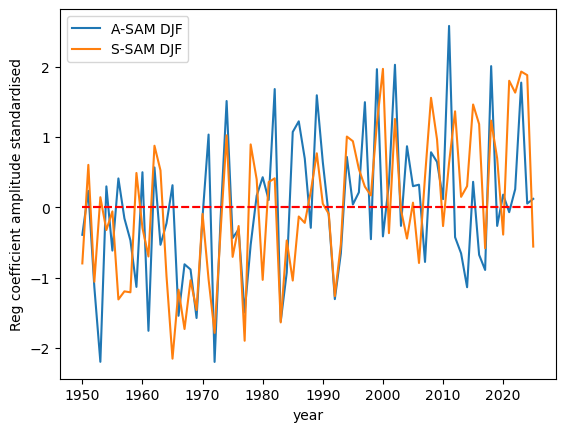

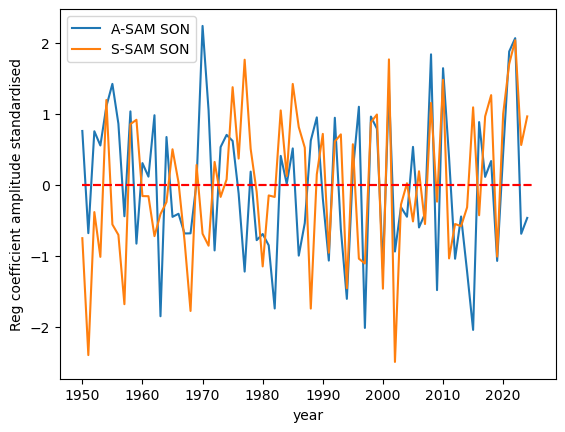

In [ ]:
def make_xarray_again(array, zg_anomalies_DJF, xname):
    A_SAM_DJF_da = xr.DataArray(
        array, 
        coords={'time': zg_anomalies_DJF['time'].values}, 
        dims=['time'],
        name=xname
            )
    return A_SAM_DJF_da

A_SAM_DJF_da=make_xarray_again(A_SAM_DJF_index, zg_anomalies_DJF, 'A_SAM')
A_SAM_SON_da=make_xarray_again(A_SAM_SON_index, zg_anomalies_SON, 'A_SAM')
S_SAM_DJF_da=make_xarray_again(S_SAM_DJF_index, zg_anomalies_DJF, 'S_SAM')
S_SAM_SON_da=make_xarray_again(S_SAM_SON_index, zg_anomalies_SON, 'S_SAM')

#seasonal averages and standardise again
A_SAM_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(A_SAM_DJF_da)))
A_SAM_ssavg_SON=stdize_ssavg(seasonal_average(shift_december(A_SAM_SON_da)))
S_SAM_ssavg_DJF=stdize_ssavg(seasonal_average(shift_december(S_SAM_DJF_da)))
S_SAM_ssavg_SON=stdize_ssavg(seasonal_average(shift_december(S_SAM_SON_da)))

A_SAM_ssavg_DJF.plot(label='A-SAM DJF')
plt.hlines(np.mean(A_SAM_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
S_SAM_ssavg_DJF.plot(label='S-SAM DJF')
plt.hlines(np.mean(S_SAM_ssavg_DJF),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.ylabel('Reg coefficient amplitude standardised')
plt.legend()
plt.show()
A_SAM_ssavg_SON.plot(label='A-SAM SON')
plt.hlines(np.mean(A_SAM_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
S_SAM_ssavg_SON.plot(label='S-SAM SON')
plt.hlines(np.mean(S_SAM_ssavg_SON),xmin=1950, xmax=2025, color='red', linestyle='dashed')
plt.ylabel('Reg coefficient amplitude standardised')
plt.legend()
plt.show()

In [ ]:
#display((A_SAM_ssavg_DJF))

# Gather everything in one pandas dataframe

In [ ]:
def convert_to_pandas(X, name, var1=False):
   # if var1=='time':
        time_list = list(X[var1].values)  # Extract time values correctly
        df = pd.DataFrame({name: X.values}, index=time_list)  # Create DataFrame
    #else: 
     #   time_list=list(max_lat_smoothed[var1].values)
      #  df = pd.DataFrame({name: X}, index=time_list)  # Create DataFrame
        return df

def dataframe_maker(somelist, name_list):
    btw_list=[]
    for i, item in enumerate(somelist):
    #print(item.variables)
        a=convert_to_pandas(item, name_list[i], 'year')
        btw_list.append(a)
        era_DJF_Andes_df=pd.concat(btw_list, axis=1)
    return era_DJF_Andes_df

def exclude_years(df, yearlist):
    df_new=df.drop(year for year in yearlist if year in df.index)
    return df_new

In [ ]:
time_list=list(iod_nino_list_upd[0]['time_bnds'].year.values)
print(time_list)
#SAM still missing
#gather all stuff sorted
###Observations
##Andes
#DJF
obs_DJF_Andes_list=[tas_Andes_ssavg_DJF,pr_Andes_ssavg_DJF['precip'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF, SPV_ssavg_DJF,\
                        A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
obs_SON_Andes_list=[tas_Andes_ssavg_SON,pr_Andes_ssavg_SON['precip'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                   A_SAM_ssavg_SON, S_SAM_ssavg_SON]
##La Plata
#DJF
obs_DJF_LaPlata_list=[tas_LaPlata_ssavg_DJF,pr_LaPlata_ssavg_DJF['precip'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF,SPV_ssavg_DJF, \
                     A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
obs_SON_LaPlata_list=[tas_LaPlata_ssavg_SON,pr_LaPlata_ssavg_SON['precip'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                     A_SAM_ssavg_SON, S_SAM_ssavg_SON]
###ERA5
##Andes
#DJF
era_DJF_Andes_list=[t_Andes_ssavg_DJF['t2m'],pr_era_Andes_ssavg_DJF['tp'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF,SPV_ssavg_DJF, \
                   A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
era_SON_Andes_list=[t_Andes_ssavg_SON['t2m'],pr_era_Andes_ssavg_SON['tp'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                   A_SAM_ssavg_SON, S_SAM_ssavg_SON]
##LaPlata
#DJF
era_DJF_LaPlata_list=[t_LaPlata_ssavg_DJF['t2m'],pr_era_LaPlata_ssavg_DJF['tp'],iod_nino_list_upd[0]['nino34'], \
                        iod_nino_list_upd[2],edj_index_ssavg_DJF,max_lat_ssavg_DJF,max_lat_nostd_DJF,SPV_ssavg_DJF, \
                     A_SAM_ssavg_DJF, S_SAM_ssavg_DJF]
#SON
era_SON_LaPlata_list=[t_LaPlata_ssavg_SON['t2m'],pr_era_LaPlata_ssavg_SON['tp'],iod_nino_list_upd[1]['nino34'], \
                        iod_nino_list_upd[3],edj_index_ssavg_SON,max_lat_ssavg_SON,max_lat_nostd_SON,SPV_ssavg_SON, \
                     A_SAM_ssavg_SON, S_SAM_ssavg_SON]

[1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [ ]:
name_list1=['t_Andes','precip_Andes','ENSO','IOD','EDJ','EDJ_lat','EDJ_lat_nostd','SPV', 'A_SAM', 'S_SAM']
name_list2=['t_LaPlata','precip_LaPlata','ENSO','IOD','EDJ','EDJ_lat','EDJ_lat_nostd','SPV', 'A_SAM', 'S_SAM']


###Obs
##Andes
#DJF
obs_DJF_Andes_df=dataframe_maker(obs_DJF_Andes_list, name_list1)
#SON
obs_SON_Andes_df=dataframe_maker(obs_SON_Andes_list, name_list1)
##La Plata
#DJF
obs_DJF_LaPlata_df=dataframe_maker(obs_DJF_LaPlata_list, name_list2)
#SON
obs_SON_LaPlata_df=dataframe_maker(obs_SON_LaPlata_list, name_list2)

###ERA5
##Andes
#DJF
era_DJF_Andes_df=dataframe_maker(era_DJF_Andes_list, name_list1)
#SON
era_SON_Andes_df=dataframe_maker(era_SON_Andes_list, name_list1)
##La Plata
#DJF
era_DJF_LaPlata_df=dataframe_maker(era_DJF_LaPlata_list, name_list2)
#SON
era_SON_LaPlata_df=dataframe_maker(era_SON_LaPlata_list, name_list2)
display(obs_DJF_Andes_df)
#plt.plot(obs_SON_LaPlata_df['precip_LaPlata'], 'o') #again precip data starts in 1979

,t_Andes,precip_Andes,ENSO,IOD,EDJ,EDJ_lat,EDJ_lat_nostd,SPV,A_SAM,S_SAM
1950,0.870880,NaN,NaN,-1.030268,1.021749,NaN,NaN,1.071469,-0.391037,-0.797818
1951,-1.398091,NaN,-0.686614,0.255515,1.782753,-0.698485,-52.071429,0.263327,0.233046,0.603790
1952,1.541370,NaN,0.583825,0.628088,0.667732,1.358745,-48.642857,-0.631221,-1.135330,-1.058408
1953,1.020491,NaN,0.306847,1.259803,-0.505639,-0.955639,-52.500000,1.450647,-2.197377,0.143728
1954,-0.125097,NaN,0.514070,0.028294,1.655904,1.101591,-49.071429,-0.003821,0.297990,-0.323217
...,...,...,...,...,...,...,...,...,...,...
2021,0.599638,1.005320,-1.228563,0.308451,-0.460897,-2.241408,-54.642857,2.192052,-0.069131,1.799882
2022,1.128286,0.310333,-1.140083,-0.842185,0.001389,-1.469947,-53.357143,2.242373,0.258090,1.631330
2023,1.177282,-0.971906,-0.754552,0.965094,0.937672,-2.241408,-54.642857,1.701837,1.773526,1.930428
2024,1.314816,-1.458471,1.631916,4.208824,0.187465,-2.241408,-54.642857,1.850329,0.053647,1.879746


Exclude years and export them as csv

In [ ]:
years=[1950,2025]
df_list=[obs_DJF_Andes_df, obs_SON_Andes_df,obs_DJF_LaPlata_df, obs_SON_LaPlata_df,era_DJF_Andes_df, \
         era_SON_Andes_df, era_DJF_LaPlata_df, era_SON_LaPlata_df]
df_list_dropped=[]
for i, item in enumerate(df_list):
    if i in np.arange(0,len(df_list),2): #every second element is DJF
     #eliminate year 2003 and 2020 from DJF because of SSW
        years.append(2003)
        years.append(2020)
        item_drop=exclude_years(item, years)
    else:
    #eliminate year 2002 and 2019 from SON because of SSW
        years.append(2002)
        years.append(2019)
        item_drop=exclude_years(item, years)
    del years[2:] #reset years to list from above
    df_list_dropped.append(item_drop)
    #probably gonna export the pandas dataframes as csv into data_ready directory
    item_csv=item_drop.to_csv('data_ready/' + str(i)+'.csv')
display(df_list_dropped[0].index, df_list_dropped[1].index)


Index([1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962,
       1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974,
       1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2002, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024],
      dtype='int64')

Index([1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962,
       1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974,
       1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986,
       1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998,
       1999, 2000, 2001, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018, 2020, 2021, 2022, 2023, 2024],
      dtype='int64')

In [ ]:
print(list([years, 2002]))

[[1950, 2025], 2002]


# Tried some stuff

In [ ]:
#display(pr_Andes_fix['precip'].values)
time_list=list(max_lat_smoothed['time'].values)
tas_A=convert_to_pandas(tas_Andes_fix, 'tas_Andes', 'time')
tas_LP=convert_to_pandas(tas_LaPlata_fix, 'tas_LaPlata', 'time')
pr_A=convert_to_pandas(pr_Andes_fix['precip'], 'precip_Andes', 'time')
pr_LP=convert_to_pandas(pr_LaPlata_fix['precip'], 'precip_LaPlata', 'time')
edj_df=convert_to_pandas(max_lat_smoothed,'max_lat','time')
SPV_df=convert_to_pandas(SPV_index, 'SPV', 'time')
#display(SPV_df)
SAM_sym_df=pd.DataFrame({'S_SAM':S_SAM_index}, index=time_list)
SAM_asym_df=pd.DataFrame({'A_SAM':A_SAM_index}, index=time_list)
nino_df=convert_to_pandas(nino34_index['nino34'], 'nino34', 'time')
iod_df=convert_to_pandas(iod_index['IOD'], 'IOD', 'time')
big_df=pd.concat([tas_A, tas_LP, pr_A, pr_LP, edj_df, SPV_df, SAM_sym_df, SAM_asym_df, nino_df, iod_df], axis=1)
display(big_df)

,tas_Andes,tas_LaPlata,precip_Andes,precip_LaPlata,max_lat,SPV,S_SAM,A_SAM,nino34,IOD
1950-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,-14809.667969,1131.023723,NaN,NaN
1950-01-16 12:00:00,0.912970,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-02-01 00:00:00,NaN,NaN,NaN,NaN,NaN,0.806678,396.766968,3436.519695,NaN,-0.197835
1950-02-15 00:00:00,0.861402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1950-03-01 00:00:00,NaN,NaN,NaN,NaN,-48.214286,0.927153,-6777.150879,2291.673840,-1.543196,-0.244536
...,...,...,...,...,...,...,...,...,...,...
2024-10-16 12:00:00,1.643714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-01 00:00:00,NaN,NaN,0.495711,0.397684,NaN,0.553095,17649.986328,3822.265857,NaN,-0.430444
2024-11-16 00:00:00,-0.502406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-01 00:00:00,NaN,NaN,-0.466716,0.341924,NaN,NaN,-5063.766602,7489.902760,NaN,NaN


## Relationship between EDJ and SAM

,max_lat,S_SAM,A_SAM
max_lat,1.000000,-0.473773,-0.194994
S_SAM,-0.473773,1.000000,0.286918
A_SAM,-0.194994,0.286918,1.000000


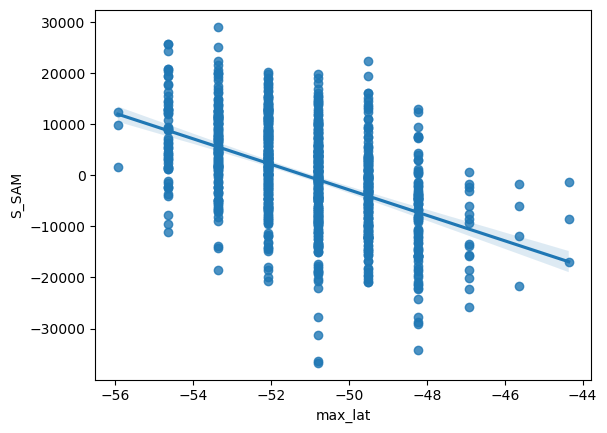

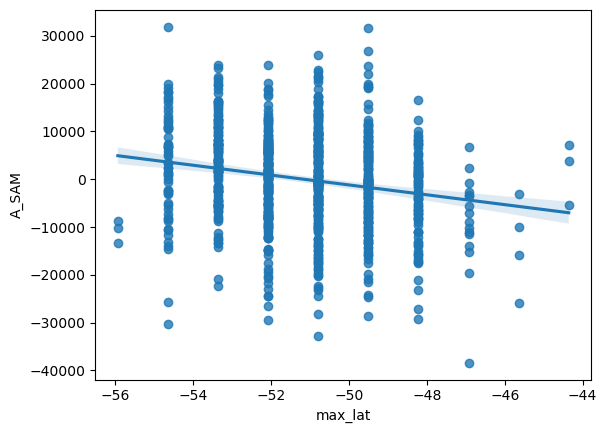

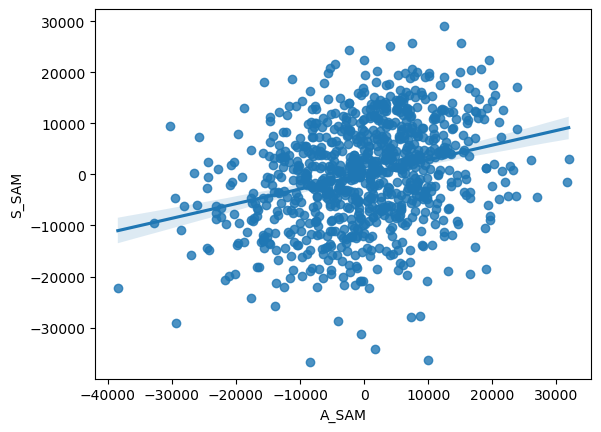

In [ ]:

#SAM_df=convert_to_pandas(SAM_zonal_mean, 'time', 'SAM')
df_corr=pd.concat([edj_df, SAM_sym_df, SAM_asym_df], axis=1)
display(df_corr.corr())
model=regplot(df_corr, x='max_lat', y='S_SAM')
plt.show()
model2=regplot(df_corr, x='max_lat', y='A_SAM')
plt.show()
model3=regplot(df_corr, x='A_SAM', y='S_SAM')
plt.show()
#model=sm.OLS(input_map)
#fit=model.fit()
#print(results)
#heatmap(df_corr.corr())

# Correlation between IOD and ENSO

,nino34,IOD
1950-03-01,-1.543196,-0.244536
1950-04-01,-1.340777,-0.081289
1950-05-01,-1.152148,-0.013153
1950-06-01,-1.036809,0.011087
1950-07-01,-0.920499,-0.035311
...,...,...
2024-06-01,0.227549,-0.055034
2024-07-01,-0.047023,-0.018379
2024-08-01,-0.184019,0.036175
2024-09-01,-0.295952,0.034286


,nino34,IOD
nino34,1.00000,0.31726
IOD,0.31726,1.00000


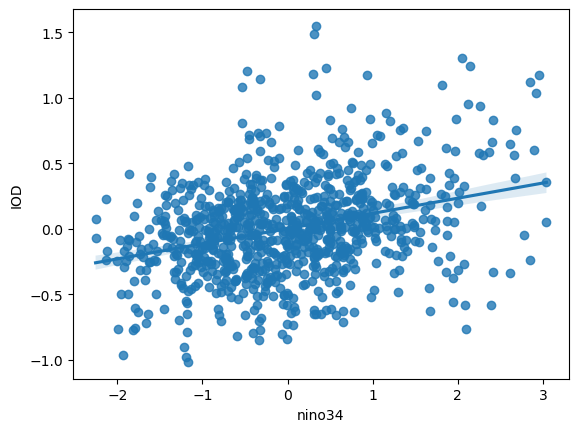

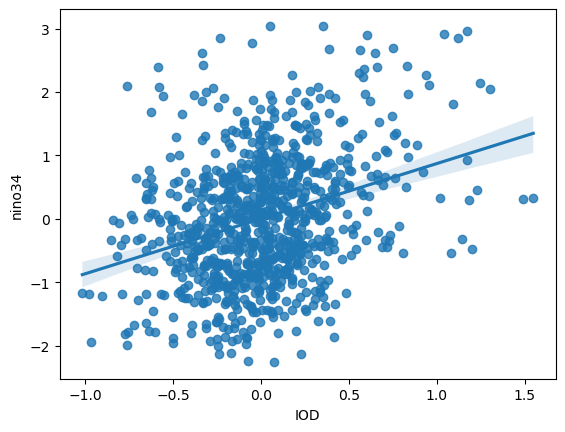

const     0.000781
nino34    0.115930
dtype: float64

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    IOD   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     100.1
Date:                Sun, 01 Jun 2025   Prob (F-statistic):           2.12e-22
Time:                        11:14:05   Log-Likelihood:                -321.81
No. Observations:                 896   AIC:                             647.6
Df Residuals:                     894   BIC:                             657.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.012      0.067      0.946      -0.022       0.024
nino34         0.1159      0.012     10.003      0.000       0.093       0.139
==============================================================================
Omnibus:                       40.793   Durbin-Watson:                   0.196
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.472
Skew:                           0.355   Prob(JB):                     2.23e-15
Kurtosis:                       4.141   Cond. No.                         1.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

const     0.000781
nino34    0.115930
dtype: float64

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    IOD   R-squared:                       0.101
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     100.1
Date:                Sun, 01 Jun 2025   Prob (F-statistic):           2.12e-22
Time:                        11:14:05   Log-Likelihood:                -321.81
No. Observations:                 896   AIC:                             647.6
Df Residuals:                     894   BIC:                             657.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.012      0.067      0.946      -0.022       0.024
nino34         0.1159      0.012     10.003      0.000       0.093       0.139
==============================================================================
Omnibus:                       40.793   Durbin-Watson:                   0.196
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               67.472
Skew:                           0.355   Prob(JB):                     2.23e-15
Kurtosis:                       4.141   Cond. No.                         1.01
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
df_corr=pd.concat([nino_df, iod_df],axis=1).dropna()
display(df_corr)
display(df_corr.corr())
model=regplot(df_corr, x='nino34', y='IOD')
plt.show()
model2=regplot(df_corr, x='IOD', y='nino34')
plt.show()

X1=sm.add_constant(df_corr['nino34'])
Y1=df_corr['IOD']
model=sm.OLS(Y1,X1)
results=model.fit()
display(results.params)
display(results.summary())
Y2=df_corr['nino34']
X2=sm.add_constant(df_corr['IOD'])
model2=sm.OLS(Y2,X2)
results2=model.fit()

display(results2.params)
display(results2.summary())
#apparently sm-ols does not like xarray, convert all to pandas best option???:(